# Создание кастомной среды и обучение DQN-агента

---
#### Цели:
- Создать кастомную среду в Gymnasium, аналогичную классической CartPole (обратный маятник)
- Обучить агента с помощью Deep Q-Network (DQN)
- Увидеть, как гиперпараметры влияют на обучение модели

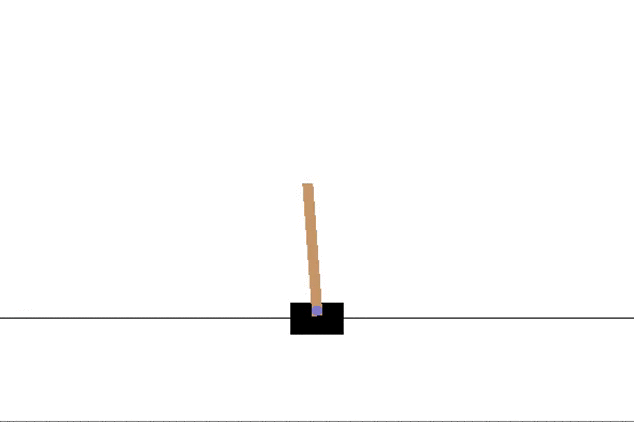

## Устанавливаем необходимые библиотеки


In [ ]:
!pip install gymnasium
!pip install pyvirtualdisplay # нужен для рендеринга в колабе

Мы будем создавать среду, идентичную CartPole

Структура проекта:


```
romanbranovets@romanbranovets-TBk-14-G7-AHP:~/projects/RL$ tree
.
├── gymnasium_env_RL
│   ├── envs
│   │   ├── cartpole_DQN_train.py
│   │   ├── cartpole_env.py
│   │   ├── __init__.py
│   ├── __init__.py
├── pyproject.toml
├── run_DQN_cartpole.py
├── setup.py

```

Удаление всех предыдущих файлов (чтобы избегать ошибок при долгой работе с ноутбуком)

In [ ]:
! rm -r /content/*

## Создание необходимых файлов (структуры проекта)

Эти файлы делают проект устанавливаемым для `pip install -e .`

In [ ]:
!mkdir -p RL/gymnasium_env_RL/envs

`setup.py` и `pyproject.toml` — файлы конфигурации пакета. Они описывают, как установить пакет: какие зависимости нужны (`gymnasium`, `pygame`, `...`), имя пакета и т.д.

In [ ]:
%%writefile RL/setup.py

from setuptools import setup

setup(
    name='gymnasium_env_RL',
    version='0.1.0',
    packages=['envs'],
)

Writing RL_course_2/setup.py


In [ ]:
%%writefile RL/pyproject.toml

[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

[tool.hatch.build.targets.wheel]
packages = ["gymnasium_env_RL"]

[project]
name = "gymnasium_env_RL"
version = "0.0.1"
dependencies = [
  "gymnasium",
  "pygame>=2.1.3",
  "pre-commit",
]

Writing RL_course_2/pyproject.toml


Создаем `__init__.py` файлы, которые позволяют воспринимать директорию как python-пакет:

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/__init__.py

from gymnasium.envs.registration import register

register(
    id='gymnasium_env_RL/CartPoleEnv-v0',
    entry_point='gymnasium_env_RL.envs.cartpole_env:CartPoleEnv',
)

Writing RL_course_2/gymnasium_env_RL_course/envs/__init__.py


In [ ]:
%%writefile RL/gymnasium_env_RL/__init__.py
from gymnasium.envs.registration import register
from . import envs # импоритруем директорию со средой и первым __init__

register( # старая среда для примера
    id="gymnasium_env_RL/GridWorld-v0",
    entry_point="gymnasium_env_RL.envs:GridWorldEnv",
)


Writing RL_course_2/gymnasium_env_RL_course/__init__.py


## Создание файла среды: cartpole_env.py

В скрипте ниже мы создаем среду CartPoleEnv.
Она наследуется от gym.Env и определяет:

### Пространства действий/состояний:

- **2 действия**:
    
1. Толкаем тележку влево
2. Толкаем вправо

- **4 наблюдения**:

1. Позиция тележки
2. Угол палки
3. Скорость тележки
4. Скорость вращения палки


### Методы:

    reset() — сбрасывает среду в исходное состояние

Инициализирует среду перед началом нового эпизода.
Возвращает:
- начальное состояние среды (наблюдение)
- вспомогательную информацию

Пример: После сброса агент 'видит' тележку около центра и палку около вертикали, и эпизод начинается.


    step() —  Здесь содержится основная логика.

В этом месте агент посылает среде свое действие.
Метод принимает действие, вычисляет состояние среды после применения этого действия и возвращает кортеж из:
- нового состояния среды, награды
- статуса (terminated, truncated - закончен ли эпизод)
- вспомогательной информации

Пример: Агент толкает вправо => тележка движется, палка перемещается новое состояние, награда +1, и флаг terminated=False.

    render() — визуализация текущего состояния

Никак не влияет на логику среды, только визуализирует.
Этот метод имеет 2 режима:
- human

    отображает визуализацию в окне pygame / выводит в консоль положение тележки - выдача данных, предназначенных для человека
- rgb_array

    Возвращает массив пикселей с RGB значениями. Для программного использования.

Пример: далее мы будем использовать `mode="human"` чтобы выводить данные в консоль и `mode="rgb_array"` чтобы сохранять массив с RGB для дальнейшей реконструкции GIF.




In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        x, x_dot, theta, theta_dot = self.state # извлечение текущего состояния

        # Наше действие - толкаем тележку право или влево
        force = self.force_mag if action == 1 else -self.force_mag

        # Физика среды (обратный маятник)
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        temp = (force + self.polemass_length * theta_dot * theta_dot * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (self.length * (4.0/3.0 - self.masspole * costheta * costheta / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == 'euler': # расчёт нового состояния
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot) # обновление состояния

        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            if self.steps_beyond_terminated == 0:
                print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return np.array(self.state, dtype=np.float32), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


## Создание цикла обучения DQN: cartpole_DQN_train.py

В этом скрипте мы:
- Создаем класс DQN и инициализируем сеть
- Инициализируем созданную ранее среду
- Обучаем ее в ней, выводя награды каждый эпизод
- Сохраняем обученную модель
- Сохраняем графики с гиперпараметрами

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import pandas as pd


seed = 40000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.02   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 64  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 10  # 1-10 Частота обновления target network

# Определяем Q-сеть (нейросеть - аппроксиматор Q функции)
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

# Выбор действия
def select_action(state, epsilon, policy_net, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1) # случайное действие с вероятностью epsilon
    else:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0)
            q_values = policy_net(state)
            return q_values.argmax().item() # действие с максимальным Q

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size: # достаточно ли данных
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    # Преобразование в тензоры
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    # Вычисляем Q-values для текущих состояний и отбираем те которые соотв действиям агента
    q_values = policy_net(states).gather(1, actions)

    # Q-values для следующих состояний (используем target_net)
    next_q_values = target_net(next_states).max(1, keepdim=True)[0]
    target_q_values = rewards + (1 - dones) * gamma * next_q_values

    # Loss и обновление весов
    loss = nn.MSELoss()(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)
        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2  # MB
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)       # CPU%

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }

profiler = Profiler()



if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    # env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, action_dim) # инициализация сетей
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    replay_buffer = ReplayBuffer(MEMORY_SIZE)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, policy_net, action_dim)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.load_state_dict(policy_net.state_dict())
            profiler.stop('target_update')
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    torch.save({
        'policy_net_state_dict': policy_net.state_dict(),
        'state_dim': state_dim,
        'action_dim': action_dim,
        # Опционально:
        # 'epsilon': epsilon,
        # 'GAMMA': GAMMA,
        # 'LR': LR
    }, 'dqn_model.pth')  # Сохраняет в файл dqn_model.pth

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


## Создание скрипта для оценки модели и создания анимации: run_catpole_DQN.py

В этом скрипте мы:
- Инициализируем созданную ранее среду
- Инициализируем DQN и загружаем обученные веса
- Прогоняем эпизоды с обученным DQN агентом и сохраняем GIF

In [ ]:
%%writefile RL/run_catpole_DQN.py

import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import sys
import os
import numpy as np
import imageio
from pyvirtualdisplay import Display

project_root = os.path.dirname(os.path.abspath(__file__))  # Путь к корню проекта для импорта DQN
sys.path.append(project_root)
from gymnasium_env_RL.envs.cartpole_DQN_train import DQN

gif_filename = 'cartpole_test_DQN.gif'
fps = 15
# Параметры
# ENV_NAME = 'CartPole-v1'  # оригинальна среда
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0' # кастомная среда
STATE_DIM = 4  # позиции и скорости тележки и палки
ACTION_DIM = 2  # втолкаем вправо или влево
MAX_STEPS = 500  # лимит шагов, чтобы избежать зависания среды при успешном агенте

# Создание сети
policy_net = DQN(STATE_DIM, ACTION_DIM) # создаем такой же DQN как при обучении
policy_net.eval() # режим оценки

# Загрузка модели, обученной ранее
checkpoint = torch.load('dqn_model.pth', map_location=torch.device('cpu'), weights_only=False) # cpu, с метаданными
policy_net.load_state_dict(checkpoint['policy_net_state_dict'])
print("Модель загружена")

# Создание среды
env = gym.make(ENV_NAME, render_mode='rgb_array') # rgb array позволяет собирать кадры для gif
env = NormalizeObservation(env) # включение нормализации

# Функция для выбора действия без epsilon
def select_action(state, policy_net):
    with torch.no_grad():
        state = torch.FloatTensor(state).unsqueeze(0) # добавляем размерность батча
        q_values = policy_net(state)
        return q_values.argmax().item()

# Оценка модели
with Display(visible=0, size=(400, 300)):  # Виртуальный дисплей для фикса рендеринга в колабе

    NUM_EVAL_EPISODES = 10
    rewards = []
    all_frames = []
    for episode in range(NUM_EVAL_EPISODES):
        state, _ = env.reset() # сброс среды
        total_reward = 0
        done = False
        step_count = 0  #счётчик шагов для truncated
        while not done and step_count < MAX_STEPS:
            action = select_action(state, policy_net)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = next_state
            total_reward += reward
            step_count += 1
            img = env.render()
            if isinstance(img, np.ndarray):
                all_frames.append(img[:, :, :3])  # RGB
        rewards.append(total_reward)
        print(f"Оценка эпизода {episode + 1}: Награда = {total_reward}")

    mean_reward = sum(rewards) / len(rewards)
    print(f"Средняя награда за {NUM_EVAL_EPISODES} эпизодов: {mean_reward:.2f}")

    imageio.mimsave(gif_filename, all_frames, fps=fps)
    print(f"GIF сохранён: {gif_filename}")

env.close()

Overwriting RL_course_2/run_catpole_DQN.py


## Создание скрипта для демонстрации среды: run_env.py

В этом скрипте мы:
- Инициализируем среду
- Записываем в гифку эпизоды со случайным агентом или агентом, управляемым с клавиатуры

In [ ]:
%%writefile RL/run_env.py

import gymnasium_env_RL
import gymnasium as gym
import imageio
import os

OUTPUT_DIR = '/content/RL'
GIF_FILENAME = 'cartpole_test.gif' # имя GIF

env_id = 'gymnasium_env_RL/CartPoleEnv-v0'
num_steps = 100
render_mode = 'rgb_array'

gif_save_path = os.path.join(OUTPUT_DIR, GIF_FILENAME)

env = gym.make('gymnasium_env_RL/CartPoleEnv-v0', render_mode=render_mode)

obs, info = env.reset()
total_reward = 0
all_frames = []

for step in range(num_steps):
    action = env.action_space.sample() # рандомное действие
    # action = int(input("Action (0=left, 1=right): ")) # 0 - влево, 1 - вправо

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    frame = env.render()
    all_frames.append(frame)

    if terminated or truncated:
        print(f"Эпизод завершен, общая награда: {total_reward}")
        break

env.close()

if all_frames:
    imageio.mimsave(gif_save_path, all_frames, duration=0.05, loop=0)
    print(f"GIF сохранен: {gif_save_path}")

Overwriting RL_course_2/run_env.py


## Сборка проекта
Сборка проекта выполняется для установки зависимостей, регистрации сред в Gymnasium и добавления ссылок (что позволяет делать `import`)

In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-auze4o7e/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


## Выполнение созданных ранее скриптов
Сначала мы запустим скрипт, который просто покажет среду, которую мы создали. Можно вручную поуправлять обратным маятником или посмотреть на случайное поведение агента (для этого надо раскомментровать строку в `run_env.py` и запустить скрипт заново):

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Action (0=left, 1=right): 1
Эпизод завершен, общая награда: 10.0
1
GIF сохранен: /content/RL_course_2/cartpole_test.gif
1


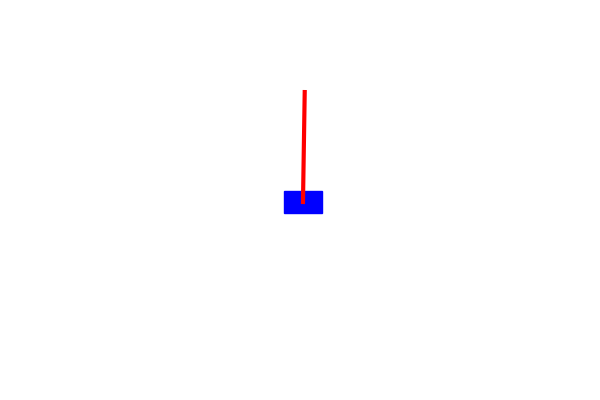

In [ ]:
!cd /content/RL/ && python run_env.py

from IPython.display import Image, display
gif_path = 'RL/cartpole_test.gif'
try:
    display(Image(filename=gif_path, width=500))
except FileNotFoundError:
    print(f"Ошибка: Файл GIF '{gif_path}' не найден.")

### Обучение DQN

Теперь перейдем к обучению нашего DQN-агента.

Далее в терминал будет выводиться номер эпизода, награда за него и эпсилон ε, актуальная для этого эпизода.

Можно увидеть, что эпсилон (вероятность совершения случайного действия) со временем экспонентециально уменьшается, это соответствует нашей деградирующей ε-жадной стратегии (decaying epsilon-greedy strategy).

In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:377: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 17.0, Epsilon: 0.985
Episode 4/600, Reward: 46.0, Epsilon: 0.980
Episode 5/600, Reward: 19.0, Epsilon: 0.975
Episode 6/600, Reward: 12.0, Epsilon: 0.970
Episode 7/600, Reward: 30.0, Epsilon: 0.966
Episode 8/60

### Оценка работы обученного агента

Посмотрим на графики обучения:
- Тонкая линия - награды за эпизод, но поскольку эпизоды во многом случайны, эти данные довольно шумные
- Толстая линия - Скользящее среднее (Running Mean) наград за эпизод, для фильтрации шумов

Мы можем видеть, что несмотря на то что обучение нестабильно (это нормально для DQN), средняя награда все же растет

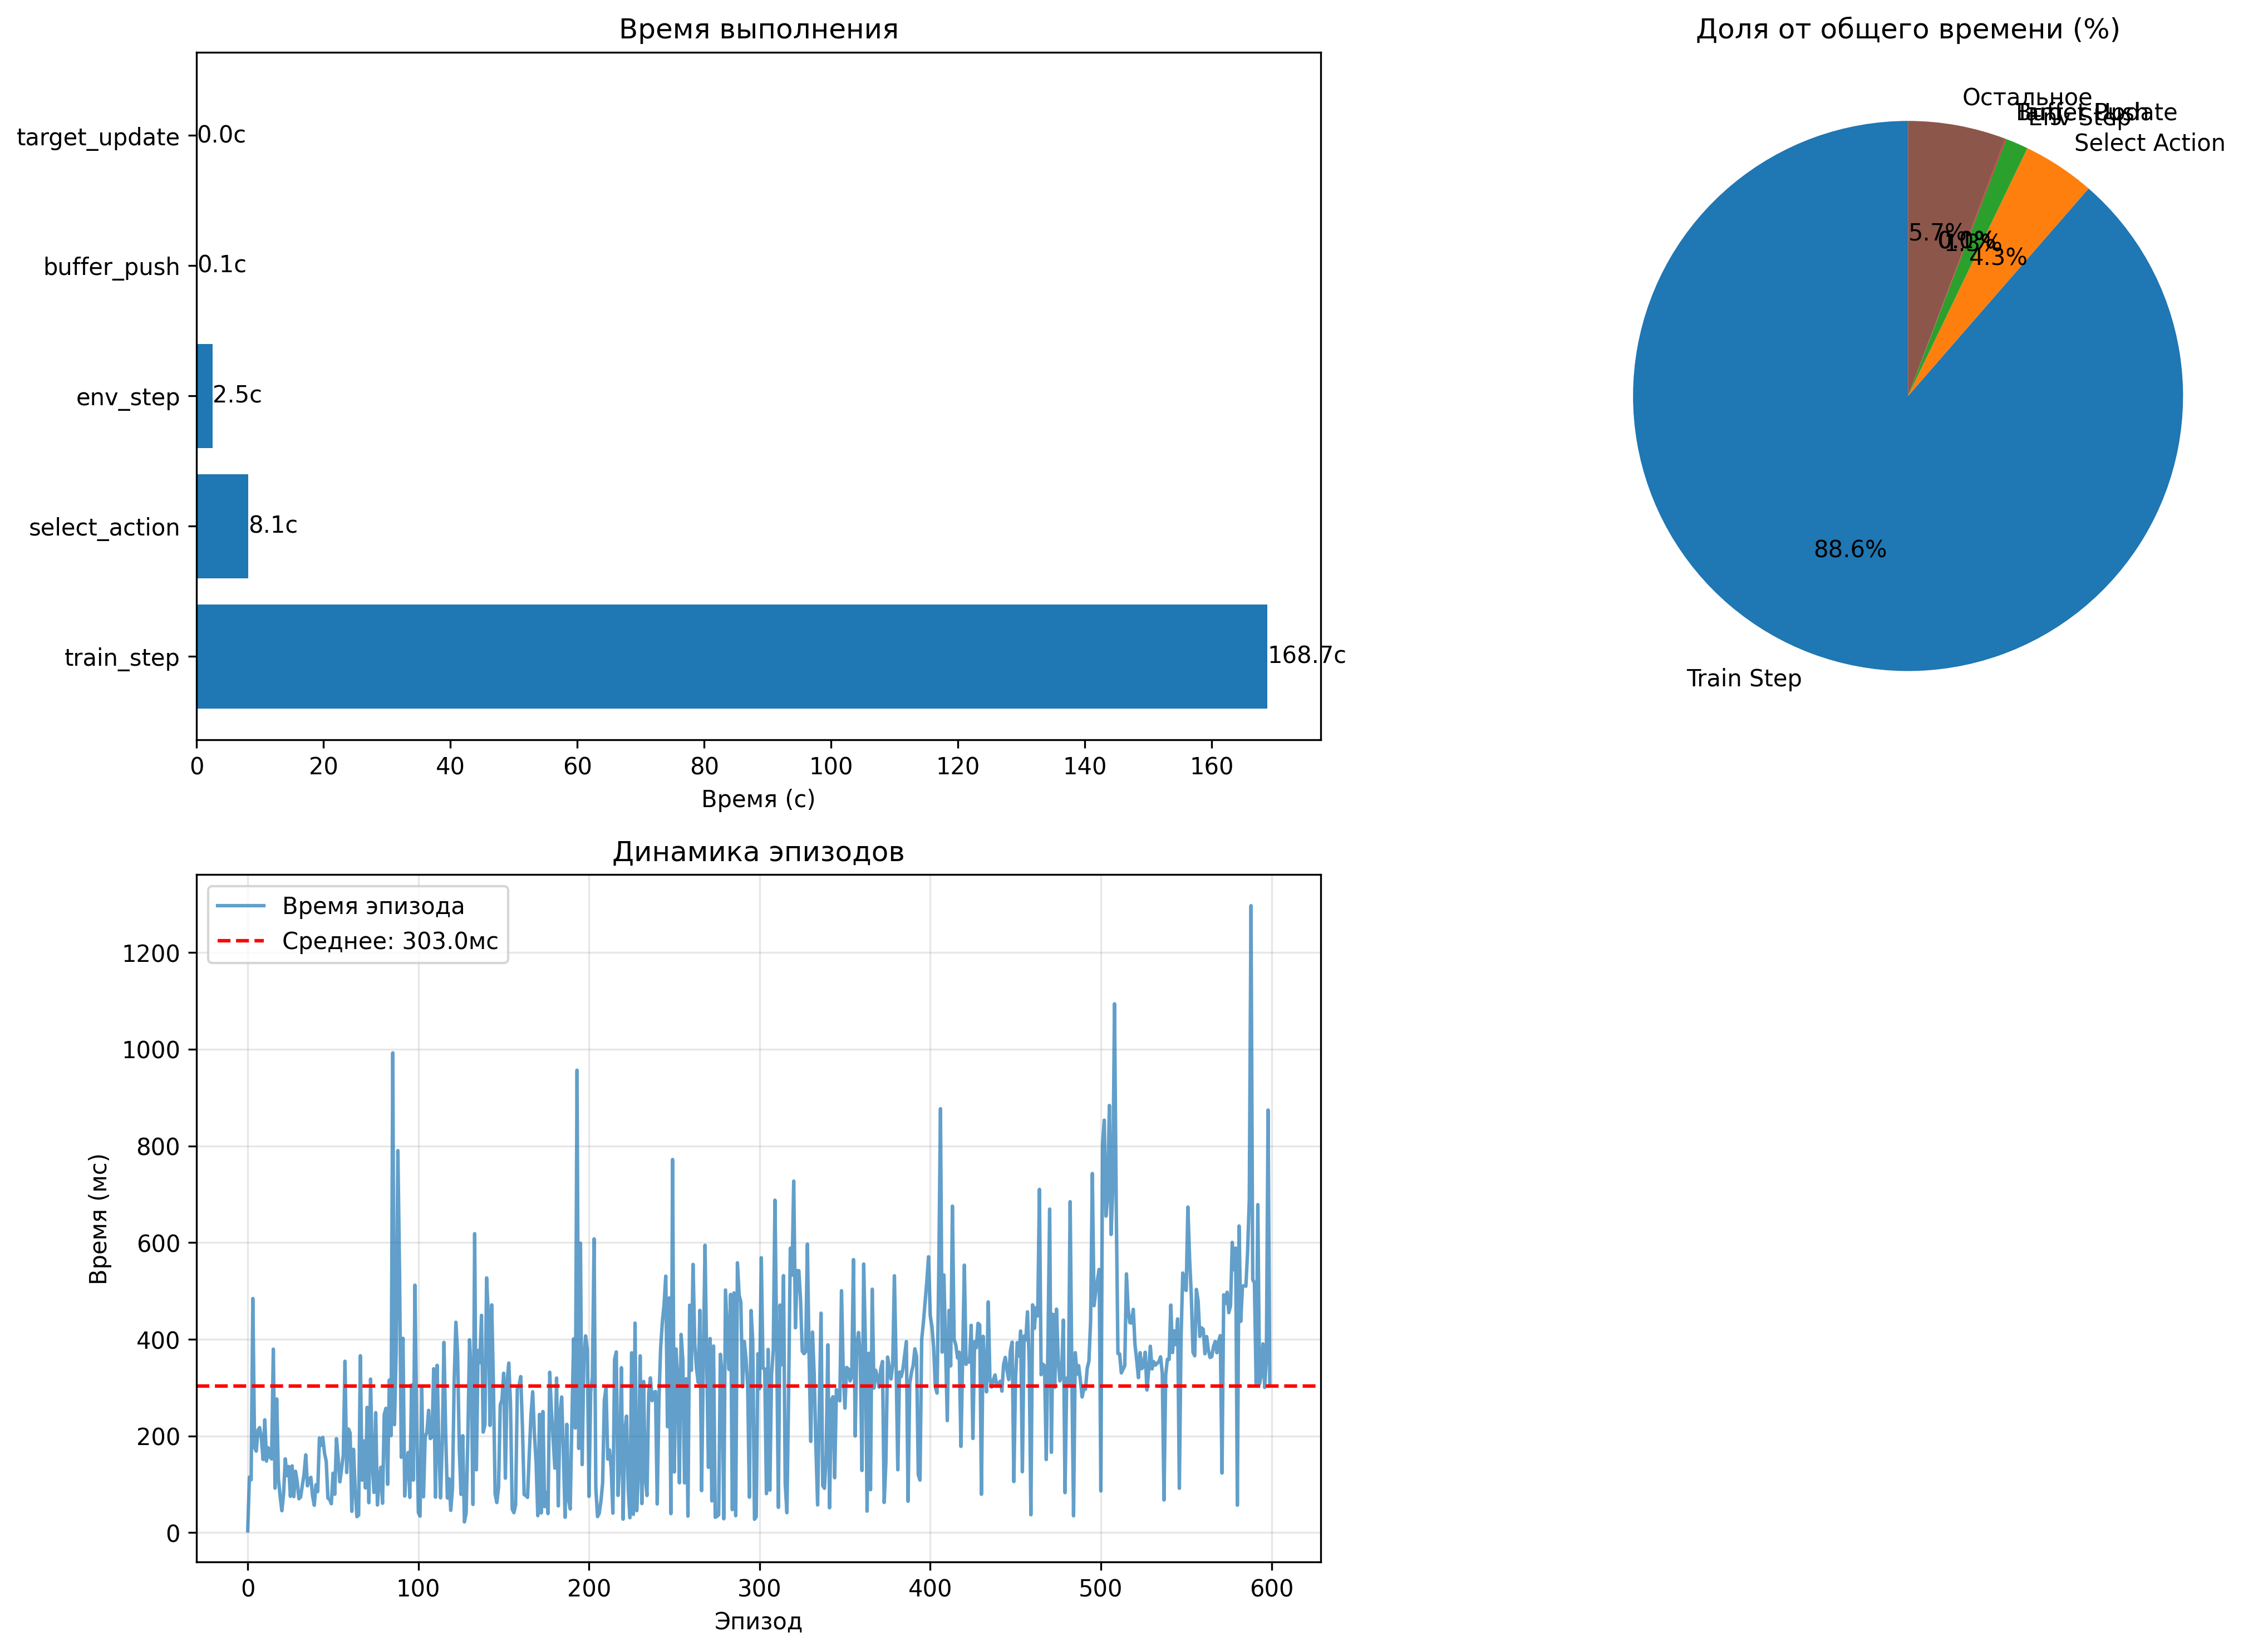

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        x, x_dot, theta, theta_dot = self.state # извлечение текущего состояния

        # Наше действие - толкаем тележку право или влево
        force = self.force_mag if action == 1 else -self.force_mag

        # Физика среды (обратный маятник)
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        temp = (force + self.polemass_length * theta_dot * theta_dot * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (self.length * (4.0/3.0 - self.masspole * costheta * costheta / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == 'euler': # расчёт нового состояния
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot) # обновление состояния

        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            if self.steps_beyond_terminated == 0:
                print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return np.array(self.state, dtype=np.float32), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import pandas as pd


seed = 40000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.01   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 128  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 8  # 1-10 Частота обновления target network

# Определяем Q-сеть (нейросеть - аппроксиматор Q функции)
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

# Выбор действия
def select_action(state, epsilon, policy_net, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1) # случайное действие с вероятностью epsilon
    else:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0)
            q_values = policy_net(state)
            return q_values.argmax().item() # действие с максимальным Q

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size: # достаточно ли данных
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    # Преобразование в тензоры
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    # Вычисляем Q-values для текущих состояний и отбираем те которые соотв действиям агента
    q_values = policy_net(states).gather(1, actions)

    # Q-values для следующих состояний (используем target_net)
    next_q_values = target_net(next_states).max(1, keepdim=True)[0]
    target_q_values = rewards + (1 - dones) * gamma * next_q_values

    # Loss и обновление весов
    loss = nn.MSELoss()(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)
        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2  # MB
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)       # CPU%

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }

profiler = Profiler()



if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    # env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, action_dim) # инициализация сетей
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    replay_buffer = ReplayBuffer(MEMORY_SIZE)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, policy_net, action_dim)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.load_state_dict(policy_net.state_dict())
            profiler.stop('target_update')
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    torch.save({
        'policy_net_state_dict': policy_net.state_dict(),
        'state_dim': state_dim,
        'action_dim': action_dim,
        # Опционально:
        # 'epsilon': epsilon,
        # 'GAMMA': GAMMA,
        # 'LR': LR
    }, 'dqn_model.pth')  # Сохраняет в файл dqn_model.pth

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Writing RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-069n98_4/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:377: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 13.0, Epsilon: 0.985
Episode 4/600, Reward: 31.0, Epsilon: 0.980
Episode 5/600, Reward: 12.0, Epsilon: 0.975
Episode 6/600, Reward: 11.0, Epsilon: 0.970
Episode 7/600, Reward: 17.0, Epsilon: 0.966
Episode 8/60

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        x, x_dot, theta, theta_dot = self.state # извлечение текущего состояния

        # Наше действие - толкаем тележку право или влево
        force = self.force_mag if action == 1 else -self.force_mag

        # Физика среды (обратный маятник)
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        temp = (force + self.polemass_length * theta_dot * theta_dot * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (self.length * (4.0/3.0 - self.masspole * costheta * costheta / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == 'euler': # расчёт нового состояния
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot) # обновление состояния

        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            if self.steps_beyond_terminated == 0:
                print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return np.array(self.state, dtype=np.float32), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha


Writing RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import pandas as pd


seed = 40000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.01   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 128  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 8  # 1-10 Частота обновления target network

# Определяем Q-сеть (нейросеть - аппроксиматор Q функции)
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

# Выбор действия
def select_action(state, epsilon, policy_net, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1) # случайное действие с вероятностью epsilon
    else:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0)
            q_values = policy_net(state)
            return q_values.argmax().item() # действие с максимальным Q

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size: # достаточно ли данных
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    # Преобразование в тензоры
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)

    # Вычисляем Q-values для текущих состояний и отбираем те которые соотв действиям агента
    q_values = policy_net(states).gather(1, actions)

    # Q-values для следующих состояний (используем target_net)
    next_q_values = target_net(next_states).max(1, keepdim=True)[0]
    target_q_values = rewards + (1 - dones) * gamma * next_q_values

    # Loss и обновление весов
    loss = nn.MSELoss()(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)
        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2  # MB
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)       # CPU%

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }

profiler = Profiler()



if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    # env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, action_dim) # инициализация сетей
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    replay_buffer = ReplayBuffer(MEMORY_SIZE)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, policy_net, action_dim)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.load_state_dict(policy_net.state_dict())
            profiler.stop('target_update')
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    torch.save({
        'policy_net_state_dict': policy_net.state_dict(),
        'state_dim': state_dim,
        'action_dim': action_dim,
        # Опционально:
        # 'epsilon': epsilon,
        # 'GAMMA': GAMMA,
        # 'LR': LR
    }, 'dqn_model.pth')  # Сохраняет в файл dqn_model.pth

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Writing RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-069n98_4/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:377: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 13.0, Epsilon: 0.985
Episode 4/600, Reward: 31.0, Epsilon: 0.980
Episode 5/600, Reward: 12.0, Epsilon: 0.975
Episode 6/600, Reward: 11.0, Epsilon: 0.970
Episode 7/600, Reward: 17.0, Epsilon: 0.966
Episode 8/60

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

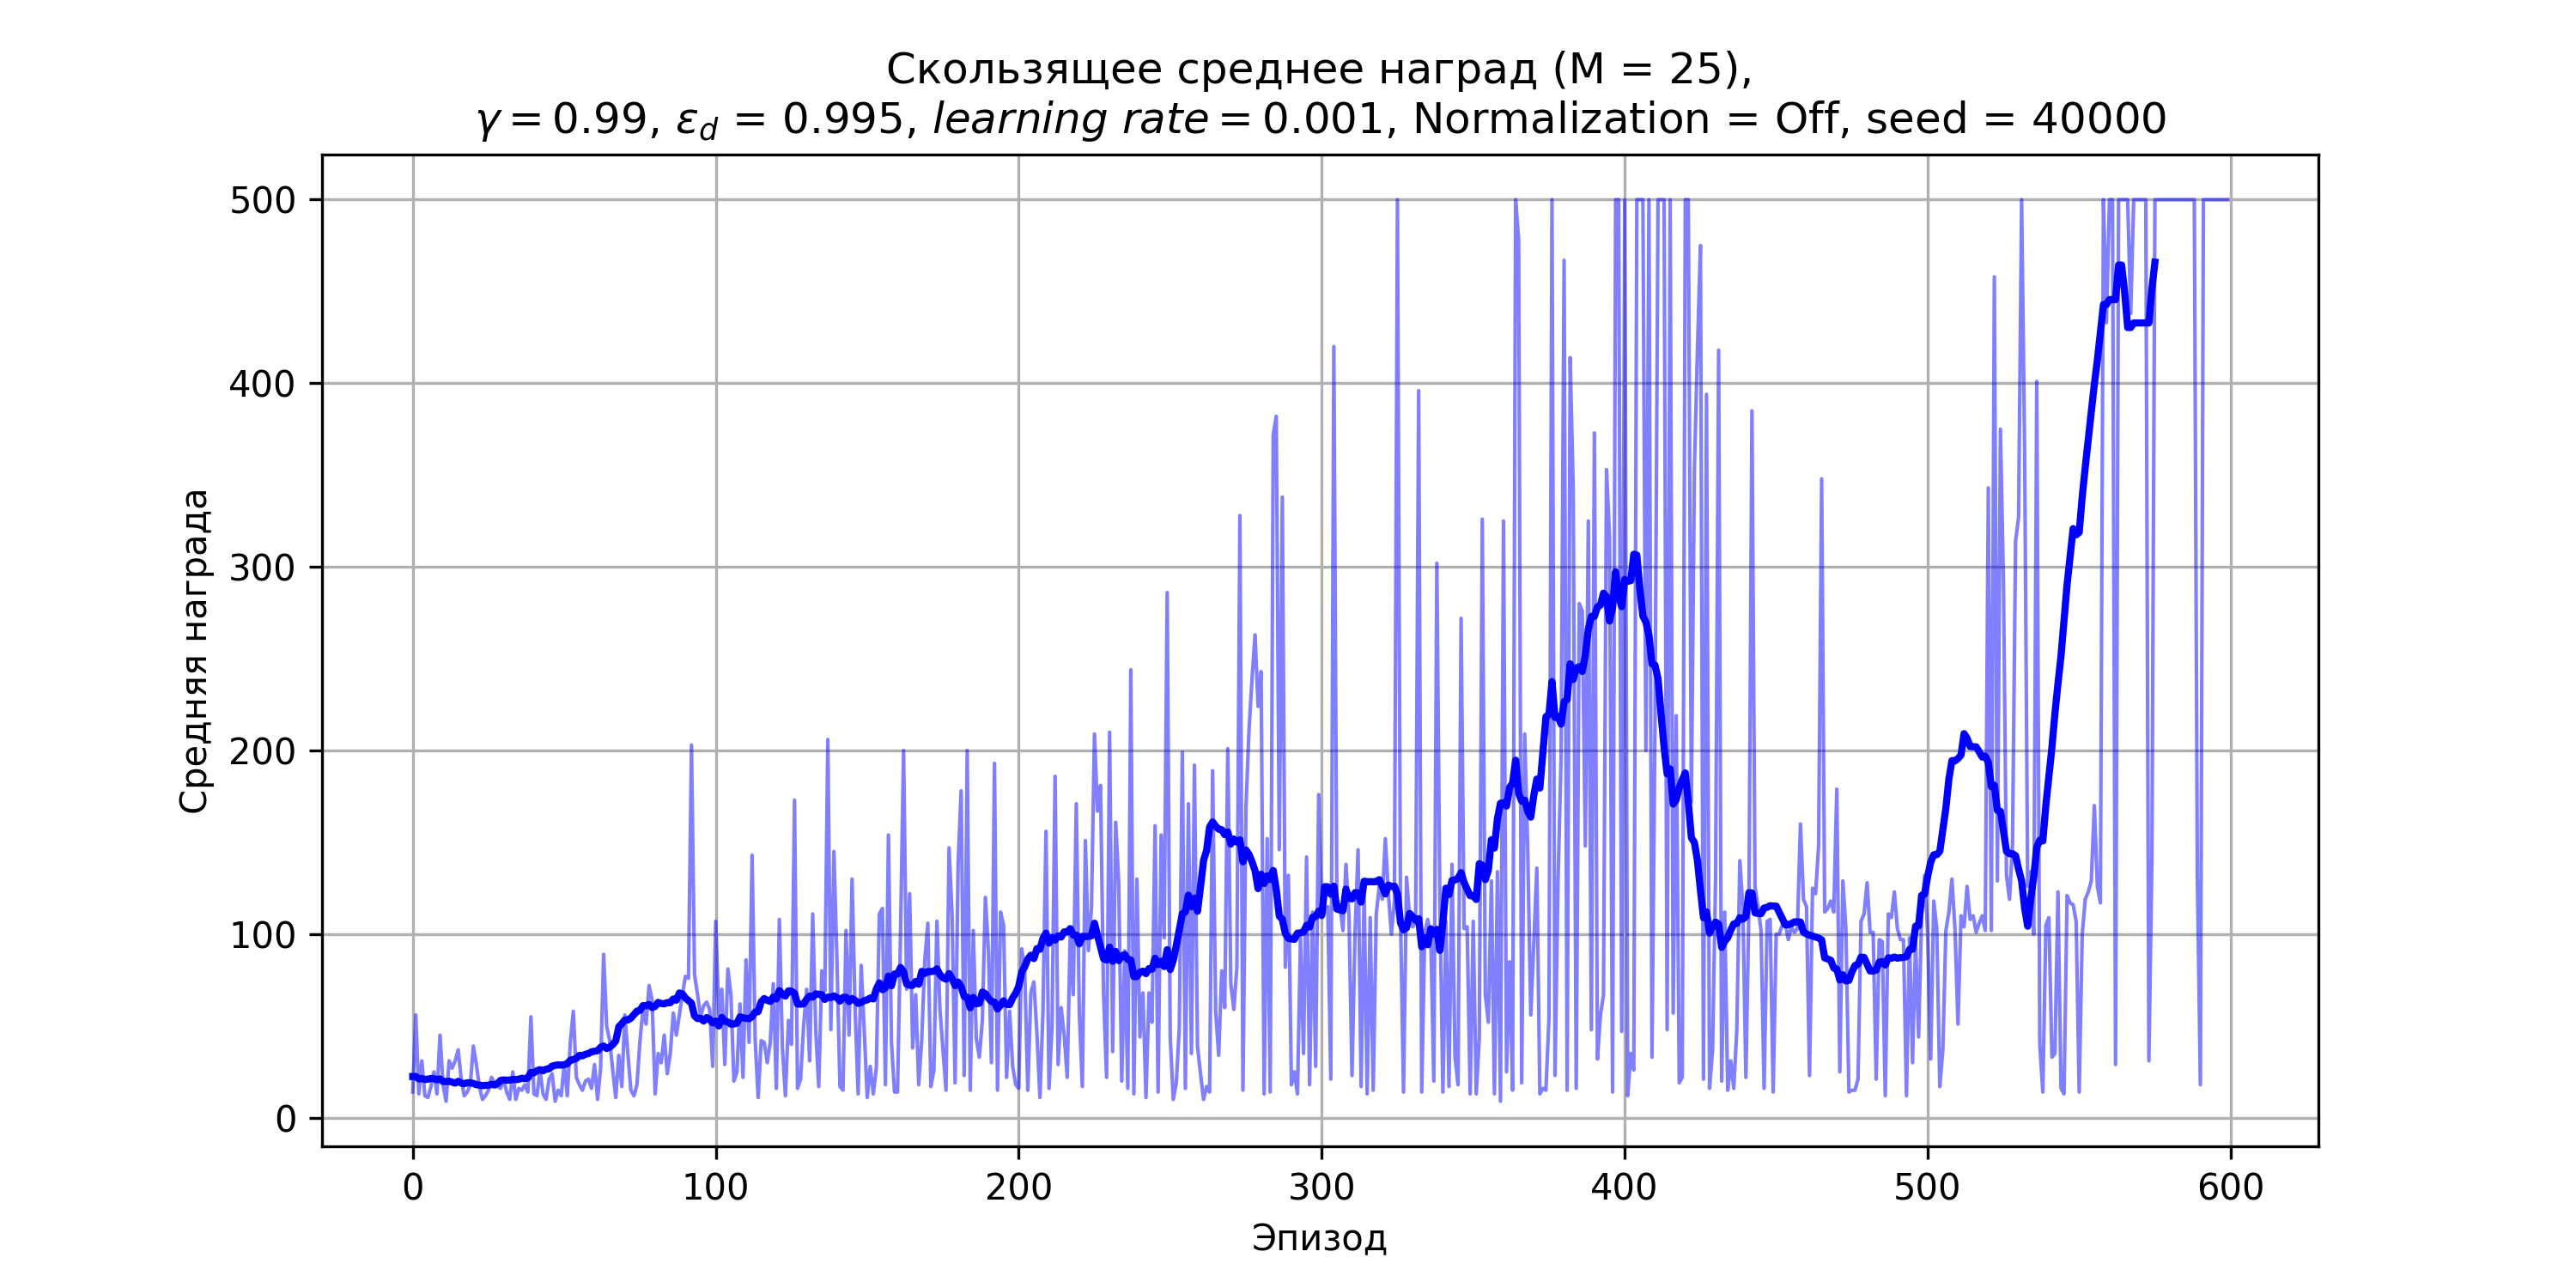

In [ ]:
image_path = 'RL/training_DQN_RunMean.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

Посмотрим, как работает наш DQN-агент:

In [ ]:
!cd /content/RL/ && python run_catpole_DQN.py

gif_path = 'RL/cartpole_test_DQN.gif'
try:
    display(Image(filename=gif_path, width=500))
except FileNotFoundError:
    print(f"Ошибка: Файл GIF '{gif_path}' не найден.")

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:377: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')


## High Performance Python applications

1. Ускорение env_step с помощью jit функции step

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from numba import njit

@njit(cache=True, fastmath=True)
def jit_step(state, action):
    gravity = 9.81
    masscart = 1.0
    masspole = 0.1
    total_mass = 1.1
    length = 0.5
    polemass_length = 0.05
    force_mag = 10.0
    tau = 0.02

    x = state[0]; x_dot = state[1]; theta = state[2]; theta_dot = state[3]
    force = force_mag if action == 1 else -force_mag

    costheta = np.cos(theta)
    sintheta = np.sin(theta)
    temp = (force + polemass_length * theta_dot * theta_dot * sintheta) / total_mass
    thetaacc = (gravity * sintheta - costheta * temp) / (
        length * (4.0/3.0 - masspole * costheta * costheta / total_mass)
    )
    xacc = temp - polemass_length * thetaacc * costheta / total_mass

    state[0] = x + tau * x_dot
    state[1] = x_dot + tau * xacc
    state[2] = theta + tau * theta_dot
    state[3] = theta_dot + tau * thetaacc

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

        test = np.array([0.0, 0.0, 0.1, 0.0], dtype=np.float32)
        jit_step(test, 0)
        jit_step(test, 1)

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        action = int(action)
        jit_step(self.state, action)
        x, x_dot, theta, theta_dot = self.state
        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            #if self.steps_beyond_terminated == 0:
            #    print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return self.state.copy(), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,)).astype(np.float32)
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import pandas as pd


seed = 40000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.02   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 64  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 10  # 1-10 Частота обновления target network

# Определяем Q-сеть (нейросеть - аппроксиматор Q функции)
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

class FastReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        # предварительная аллокация памяти
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        idx = self.ptr % self.capacity

        self.states[idx] = state
        self.actions[idx] = action
        self.rewards[idx] = reward
        self.next_states[idx] = next_state
        self.dones[idx] = done

        self.ptr += 1
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        # векторизированные индексы
        idxs = np.random.randint(0, self.size, size=batch_size)

        return (
            self.states[idxs],
            self.actions[idxs],
            self.rewards[idxs],
            self.next_states[idxs],
            self.dones[idxs]
        )

    def __len__(self):
        return self.size

# Выбор действия
def select_action(state, epsilon, policy_net, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1) # случайное действие с вероятностью epsilon
    else:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0)
            q_values = policy_net(state)
            return q_values.argmax().item() # действие с максимальным Q

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size: # достаточно ли данных
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    # Преобразование в тензоры
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    # Вычисляем Q-values для текущих состояний и отбираем те которые соотв действиям агента
    q_values = policy_net(states).gather(1, actions)

    # Q-values для следующих состояний (используем target_net)
    next_q_values = target_net(next_states).max(1, keepdim=True)[0]
    target_q_values = rewards + (1 - dones) * gamma * next_q_values

    # Loss и обновление весов
    loss = nn.MSELoss()(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)

        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }


profiler = Profiler()



if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    #env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, action_dim) # инициализация сетей
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    # replay_buffer = ReplayBuffer(MEMORY_SIZE)
    replay_buffer = FastReplayBuffer(MEMORY_SIZE, state_dim, 1)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, policy_net, action_dim)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.load_state_dict(policy_net.state_dict())
            profiler.stop('target_update')
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    torch.save({
        'policy_net_state_dict': policy_net.state_dict(),
        'state_dim': state_dim,
        'action_dim': action_dim,
        # Опционально:
        # 'epsilon': epsilon,
        # 'GAMMA': GAMMA,
        # 'LR': LR
    }, 'dqn_model.pth')  # Сохраняет в файл dqn_model.pth

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
%%writefile RL/run_catpole_DQN.py

import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import sys
import os
import numpy as np
import imageio
from pyvirtualdisplay import Display

project_root = os.path.dirname(os.path.abspath(__file__))  # Путь к корню проекта для импорта DQN
sys.path.append(project_root)
from gymnasium_env_RL.envs.cartpole_DQN_train import DQN

gif_filename = 'cartpole_test_DQN.gif'
fps = 15
# Параметры
# ENV_NAME = 'CartPole-v1'  # оригинальна среда
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0' # кастомная среда
STATE_DIM = 4  # позиции и скорости тележки и палки
ACTION_DIM = 2  # втолкаем вправо или влево
MAX_STEPS = 500  # лимит шагов, чтобы избежать зависания среды при успешном агенте

# Создание сети
policy_net = DQN(STATE_DIM, ACTION_DIM) # создаем такой же DQN как при обучении
policy_net.eval() # режим оценки

# Загрузка модели, обученной ранее
checkpoint = torch.load('dqn_model.pth', map_location=torch.device('cpu'), weights_only=False) # cpu, с метаданными
policy_net.load_state_dict(checkpoint['policy_net_state_dict'])
print("Модель загружена")

# Создание среды
env = gym.make(ENV_NAME, render_mode='rgb_array') # rgb array позволяет собирать кадры для gif
env = NormalizeObservation(env) # включение нормализации

# Функция для выбора действия без epsilon
def select_action(state, policy_net):
    with torch.no_grad():
        state = torch.FloatTensor(state).unsqueeze(0) # добавляем размерность батча
        q_values = policy_net(state)
        return q_values.argmax().item()

# Оценка модели
with Display(visible=0, size=(400, 300)):  # Виртуальный дисплей для фикса рендеринга в колабе

    NUM_EVAL_EPISODES = 10
    rewards = []
    all_frames = []
    for episode in range(NUM_EVAL_EPISODES):
        state, _ = env.reset() # сброс среды
        total_reward = 0
        done = False
        step_count = 0  #счётчик шагов для truncated
        while not done and step_count < MAX_STEPS:
            action = select_action(state, policy_net)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = next_state
            total_reward += reward
            step_count += 1
            img = env.render()
            if isinstance(img, np.ndarray):
                all_frames.append(img[:, :, :3])  # RGB
        rewards.append(total_reward)
        print(f"Оценка эпизода {episode + 1}: Награда = {total_reward}")

    mean_reward = sum(rewards) / len(rewards)
    print(f"Средняя награда за {NUM_EVAL_EPISODES} эпизодов: {mean_reward:.2f}")

    imageio.mimsave(gif_filename, all_frames, fps=fps)
    print(f"GIF сохранён: {gif_filename}")

env.close()

Overwriting RL_course_2/run_catpole_DQN.py


In [ ]:
%%writefile RL/run_env.py

import gymnasium_env_RL
import gymnasium as gym
import imageio
import os

OUTPUT_DIR = '/content/RL'
GIF_FILENAME = 'cartpole_test.gif' # имя GIF

env_id = 'gymnasium_env_RL/CartPoleEnv-v0'
num_steps = 100
render_mode = 'rgb_array'

gif_save_path = os.path.join(OUTPUT_DIR, GIF_FILENAME)

env = gym.make('gymnasium_env_RL/CartPoleEnv-v0', render_mode=render_mode)

obs, info = env.reset()
total_reward = 0
all_frames = []

for step in range(num_steps):
    # action = env.action_space.sample() # рандомное действие
    action = int(input("Action (0=left, 1=right): ")) # 0 - влево, 1 - вправо

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    frame = env.render()
    all_frames.append(frame)

    if terminated or truncated:
        print(f"Эпизод завершен, общая награда: {total_reward}")
        break

env.close()

if all_frames:
    imageio.mimsave(gif_save_path, all_frames, duration=0.05, loop=0)
    print(f"GIF сохранен: {gif_save_path}")

Overwriting RL_course_2/run_env.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-txerx11j/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:420: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 12.0, Epsilon: 0.985
Episode 4/600, Reward: 18.0, Epsilon: 0.980
Episode 5/600, Reward: 18.0, Epsilon: 0.975
Episode 6/600, Reward: 28.0, Epsilon: 0.970
Episode 7/600, Reward: 21.0, Epsilon: 0.966
Episode 8/60

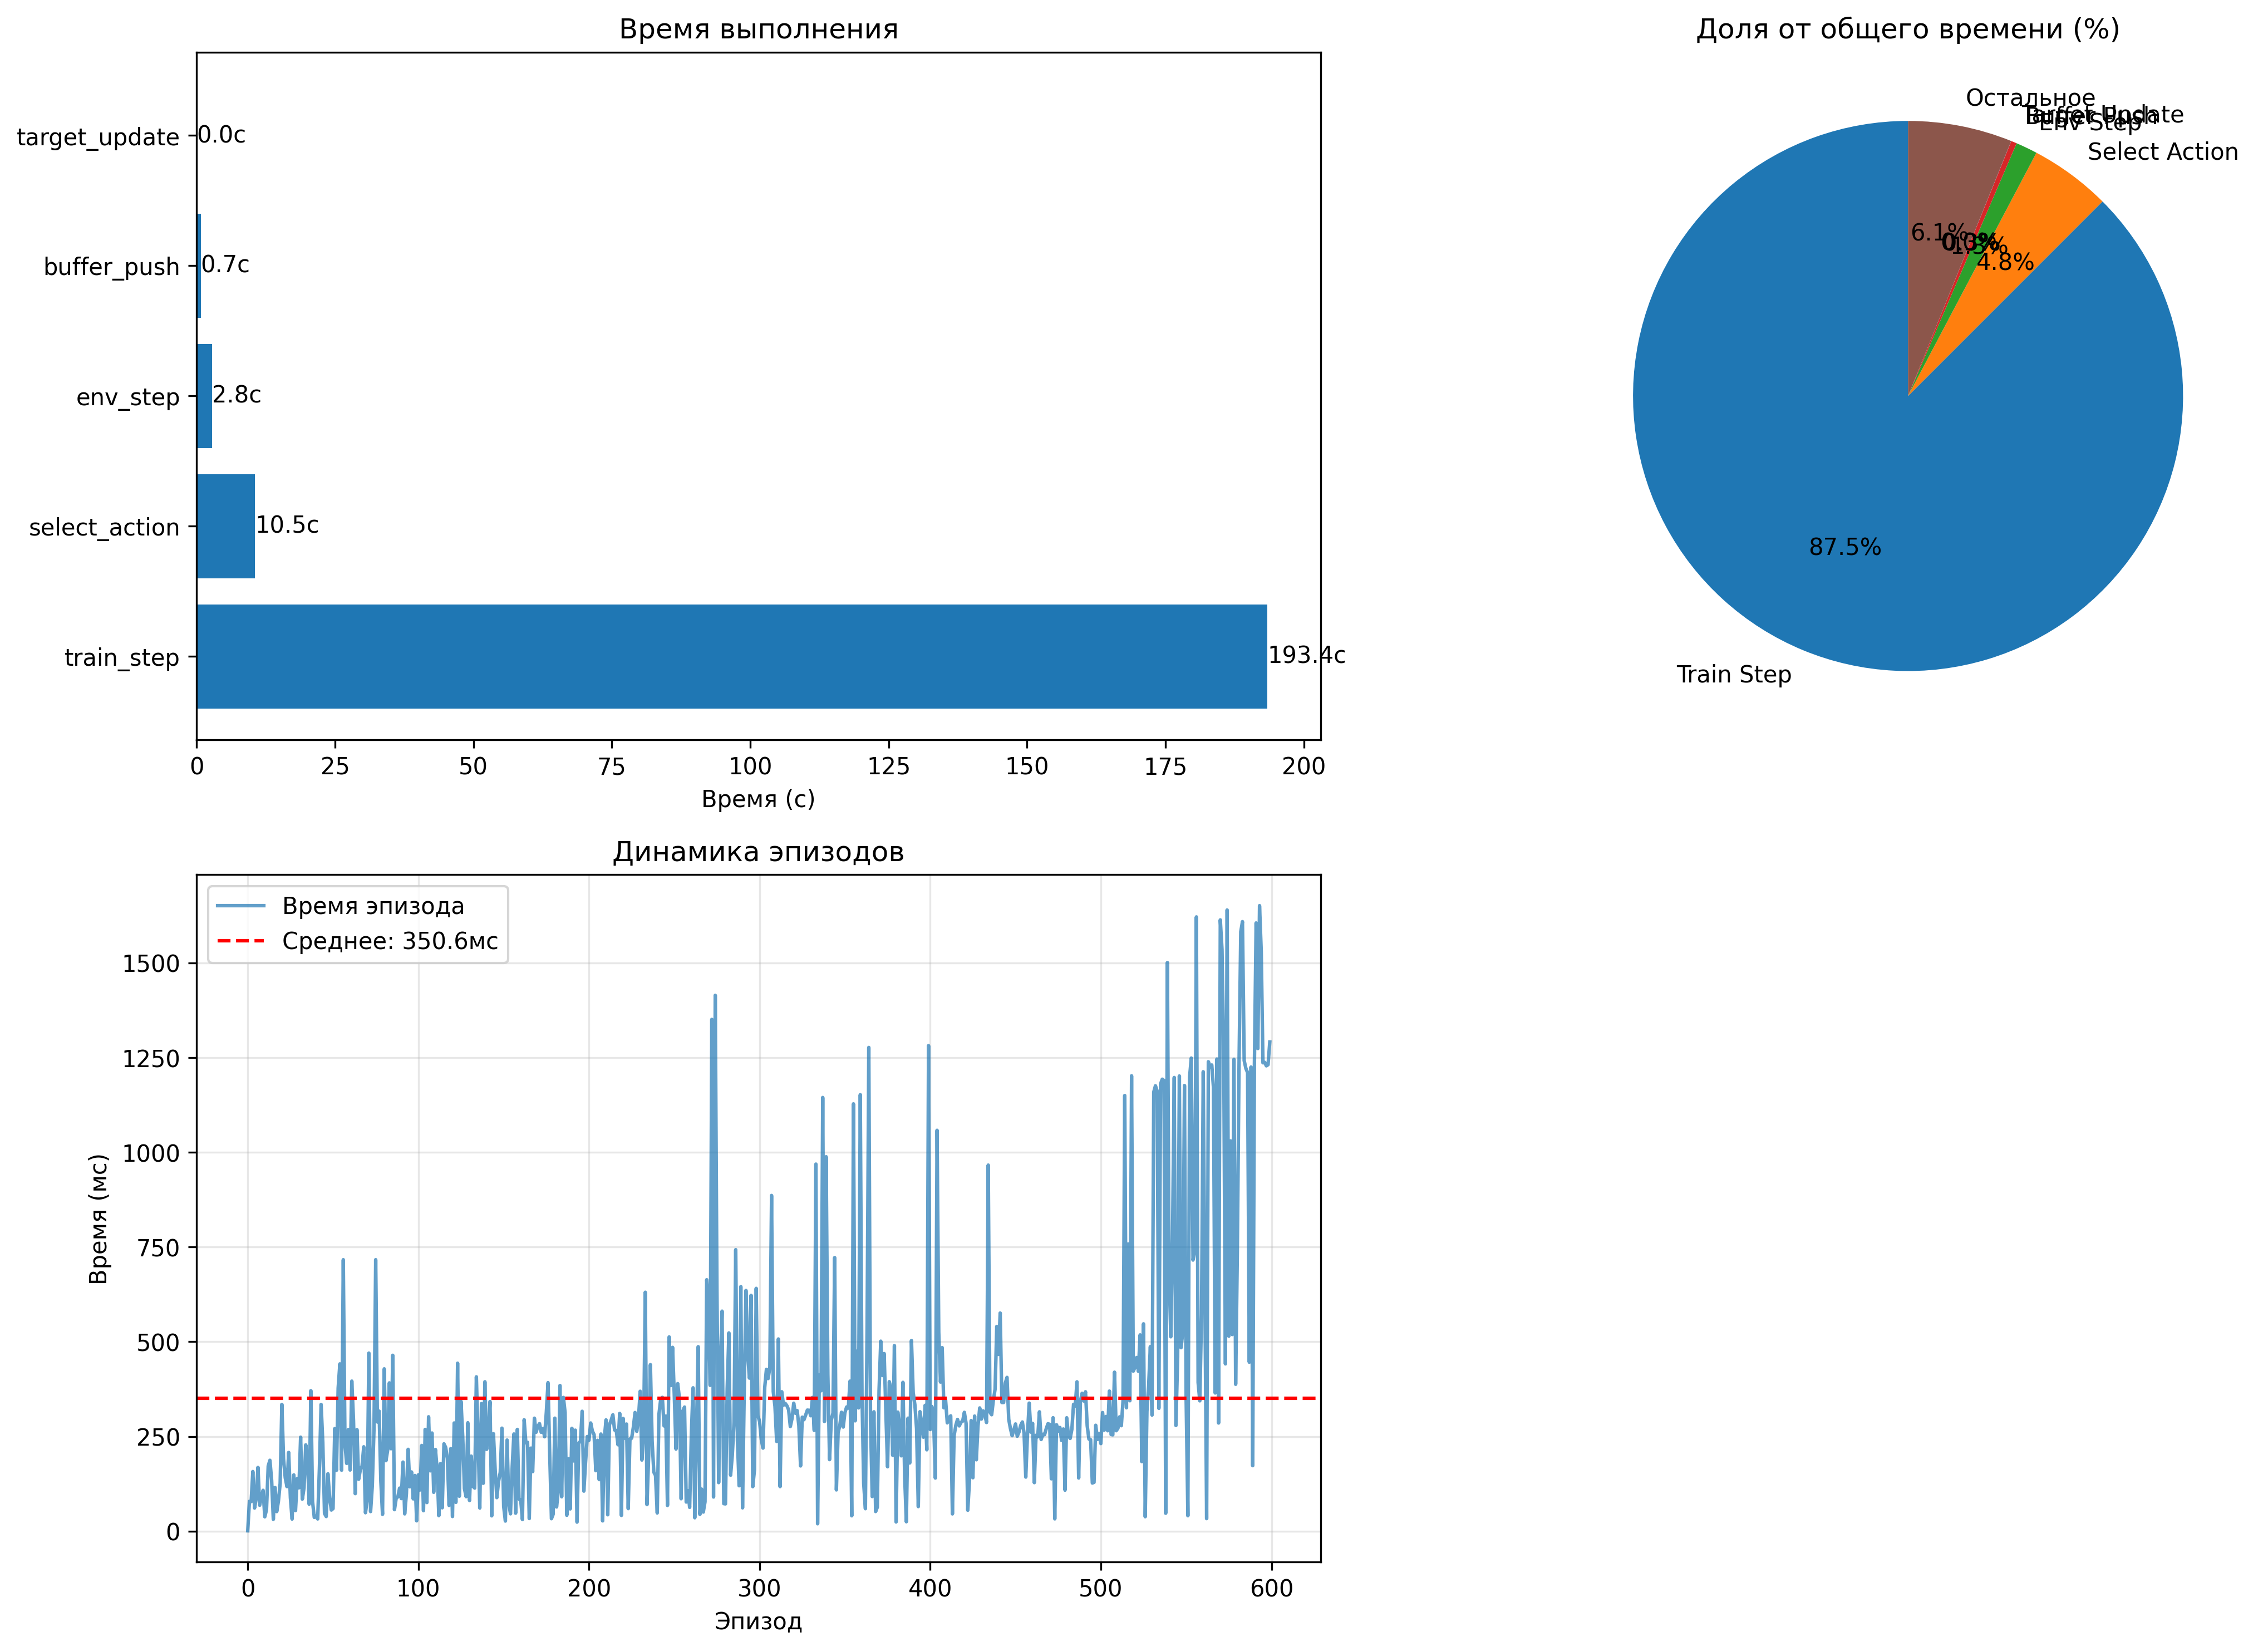

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

Ускорение train_step с помощью Cuda


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from numba import njit

@njit(cache=True, fastmath=True)
def jit_step(state, action):
    gravity = 9.81
    masscart = 1.0
    masspole = 0.1
    total_mass = 1.1
    length = 0.5
    polemass_length = 0.05
    force_mag = 10.0
    tau = 0.02

    x = state[0]; x_dot = state[1]; theta = state[2]; theta_dot = state[3]
    force = force_mag if action == 1 else -force_mag

    costheta = np.cos(theta)
    sintheta = np.sin(theta)
    temp = (force + polemass_length * theta_dot * theta_dot * sintheta) / total_mass
    thetaacc = (gravity * sintheta - costheta * temp) / (
        length * (4.0/3.0 - masspole * costheta * costheta / total_mass)
    )
    xacc = temp - polemass_length * thetaacc * costheta / total_mass

    state[0] = x + tau * x_dot
    state[1] = x_dot + tau * xacc
    state[2] = theta + tau * theta_dot
    state[3] = theta_dot + tau * thetaacc

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

        test = np.array([0.0, 0.0, 0.1, 0.0], dtype=np.float32)
        jit_step(test, 0)
        jit_step(test, 1)

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        action = int(action)
        jit_step(self.state, action)
        x, x_dot, theta, theta_dot = self.state
        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            #if self.steps_beyond_terminated == 0:
            #    print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return self.state.copy(), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,)).astype(np.float32)
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha

Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import cupy as cp
from cupy import RawKernel


seed = 40000
random.seed(seed)
np.random.seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.02   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 64  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 10  # 1-10 Частота обновления target network


k_td = RawKernel(r'''
extern "C" __global__
void td_grad_2a(const float* Q, const float* Qnext,
                const int* actions,
                const float* rewards,
                const float* dones,
                float gamma,
                float* dLdQ,     // [B,2]
                float* loss_out, // [B]
                int B) {
    int i = (int)(blockDim.x * blockIdx.x + threadIdx.x);
    if (i >= B) return;

    float q0 = Q[i*2 + 0];
    float q1 = Q[i*2 + 1];
    int a = actions[i] & 1;

    float q_sa = (a == 0) ? q0 : q1;

    float nq0 = Qnext[i*2 + 0];
    float nq1 = Qnext[i*2 + 1];
    float max_next = (nq0 > nq1) ? nq0 : nq1;

    float t = rewards[i] + (1.0f - dones[i]) * gamma * max_next;
    float diff = q_sa - t;

    // mean MSE: grad = 2*diff/B
    float g = 2.0f * diff / (float)B;

    dLdQ[i*2 + 0] = 0.0f;
    dLdQ[i*2 + 1] = 0.0f;
    dLdQ[i*2 + a] = g;

    loss_out[i] = diff * diff;
}
''', "td_grad_2a")

class DQN():
    def __init__(self, state_dim=4, h1=128, h2=128, action_dim=2, lr=2e-3, seed=40000):
        self.S, self.H1, self.H2, self.A = state_dim, h1, h2, action_dim
        self.lr = float(lr)
        cp.random.seed(seed)

        self.W1 = (cp.random.randn(self.S, self.H1).astype(cp.float32) * cp.float32(0.1))
        self.b1 = cp.zeros((self.H1,), dtype=cp.float32)
        self.W2 = (cp.random.randn(self.H1, self.H2).astype(cp.float32) * cp.float32(0.1))
        self.b2 = cp.zeros((self.H2,), dtype=cp.float32)
        self.W3 = (cp.random.randn(self.H2, self.A).astype(cp.float32) * cp.float32(0.1))
        self.b3 = cp.zeros((self.A,), dtype=cp.float32)

    def copy_from(self, other: "DQN"):
        self.W1 = other.W1.copy()
        self.b1 = other.b1.copy()
        self.W2 = other.W2.copy()
        self.b2 = other.b2.copy()
        self.W3 = other.W3.copy()
        self.b3 = other.b3.copy()

    @staticmethod
    def relu(x):
        return cp.maximum(x, cp.float32(0.0))

    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        H1 = self.relu(Z1)
        Z2 = H1 @ self.W2 + self.b2
        H2 = self.relu(Z2)
        Q  = H2 @ self.W3 + self.b3
        cache = (X, Z1, H1, Z2, H2)
        return Q, cache

    def train_step_cuda(self, target_net: "DQN",
                        states, actions, rewards, next_states, dones, gamma=0.99):

        B = int(states.shape[0])

        Q, cache = self.forward(states)
        with cp.cuda.Stream.null:
            Qnext, _ = target_net.forward(next_states)

        dLdQ = cp.empty((B, self.A), dtype=cp.float32)
        loss_vec = cp.empty((B,), dtype=cp.float32)

        threads = 256
        blocks = (B + threads - 1) // threads
        k_td((blocks,), (threads,),
             (Q, Qnext, actions, rewards, dones, cp.float32(gamma), dLdQ, loss_vec, B))

        X, Z1, H1, Z2, H2 = cache

        dW3 = H2.T @ dLdQ
        db3 = dLdQ.sum(axis=0)
        dH2 = dLdQ @ self.W3.T


        dZ2 = dH2 * (Z2 > 0)


        dW2 = H1.T @ dZ2
        db2 = dZ2.sum(axis=0)
        dH1 = dZ2 @ self.W2.T


        dZ1 = dH1 * (Z1 > 0)


        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0)


        lr = cp.float32(self.lr)
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.W2 -= lr * dW2; self.b2 -= lr * db2
        self.W3 -= lr * dW3; self.b3 -= lr * db3

        return loss_vec.mean()

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

class FastReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        # предварительная аллокация памяти
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        idx = self.ptr % self.capacity

        self.states[idx] = state
        self.actions[idx] = action
        self.rewards[idx] = reward
        self.next_states[idx] = next_state
        self.dones[idx] = done

        self.ptr += 1
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        # векторизированные индексы
        idxs = np.random.randint(0, self.size, size=batch_size)

        return (
            self.states[idxs],
            self.actions[idxs],
            self.rewards[idxs],
            self.next_states[idxs],
            self.dones[idxs]
        )

    def __len__(self):
        return self.size

# Выбор действия
def select_action(state, epsilon, policy_net, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    s = cp.asarray(state[None, :], dtype=cp.float32)
    q, _ = policy_net.forward(s)
    return int(cp.argmax(q, axis=1).get()[0])

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # перенос на GPU
    states      = cp.asarray(states, dtype=cp.float32)
    next_states = cp.asarray(next_states, dtype=cp.float32)
    actions     = cp.asarray(actions, dtype=cp.int32)
    rewards     = cp.asarray(rewards, dtype=cp.float32)
    dones       = cp.asarray(dones, dtype=cp.float32)

    loss = policy_net.train_step_cuda(target_net, states, actions, rewards, next_states, dones, gamma=gamma)
    return float(loss.get())

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)

        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2  # MB
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)       # CPU%

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }

# Глобальный профайлер
profiler = Profiler()


# Основной код
if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    #env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, 128, 128, action_dim, lr=LR, seed=seed)
    target_net = DQN(state_dim, 128, 128, action_dim, lr=LR, seed=seed)
    target_net.copy_from(policy_net)
    optimizer = None

    # replay_buffer = ReplayBuffer(MEMORY_SIZE)
    replay_buffer = FastReplayBuffer(MEMORY_SIZE, state_dim, 1)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, policy_net, action_dim)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.copy_from(policy_net)
            profiler.stop('target_update')
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    np.savez('dqn_model_cupy.npz',
            W1=cp.asnumpy(policy_net.W1), b1=cp.asnumpy(policy_net.b1),
            W2=cp.asnumpy(policy_net.W2), b2=cp.asnumpy(policy_net.b2),
            W3=cp.asnumpy(policy_net.W3), b3=cp.asnumpy(policy_net.b3))

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
%%writefile RL/run_catpole_DQN.py

import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import sys
import os
import numpy as np
import imageio
from pyvirtualdisplay import Display
import cupy as cp

project_root = os.path.dirname(os.path.abspath(__file__))
sys.path.append(project_root)

from gymnasium_env_RL.envs.cartpole_DQN_train import DQN  # твой CuPy DQN

gif_filename = 'cartpole_test_DQN.gif'
fps = 15

ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
STATE_DIM = 4
ACTION_DIM = 2
MAX_STEPS = 500

# Создаём CuPy сеть
policy_net = DQN(state_dim=STATE_DIM, h1=128, h2=128, action_dim=ACTION_DIM, lr=0.0)

# Загружаем веса
ckpt = np.load('dqn_model_cupy.npz')
policy_net.W1 = cp.asarray(ckpt['W1'], dtype=cp.float32)
policy_net.b1 = cp.asarray(ckpt['b1'], dtype=cp.float32)
policy_net.W2 = cp.asarray(ckpt['W2'], dtype=cp.float32)
policy_net.b2 = cp.asarray(ckpt['b2'], dtype=cp.float32)
policy_net.W3 = cp.asarray(ckpt['W3'], dtype=cp.float32)
policy_net.b3 = cp.asarray(ckpt['b3'], dtype=cp.float32)


env = gym.make(ENV_NAME, render_mode='rgb_array')


def select_action(state, policy_net):
    s = cp.asarray(state[None, :], dtype=cp.float32)  # [1,4]
    q, _ = policy_net.forward(s)                      # [1,2]
    return int(cp.argmax(q, axis=1).get()[0])

with Display(visible=0, size=(400, 300)):
    NUM_EVAL_EPISODES = 10
    rewards = []
    all_frames = []

    for episode in range(NUM_EVAL_EPISODES):
        state, _ = env.reset()
        total_reward = 0.0
        done = False
        step_count = 0

        while not done and step_count < MAX_STEPS:
            action = select_action(state, policy_net)
            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated
            state = next_state
            total_reward += float(reward)
            step_count += 1

            img = env.render()
            if isinstance(img, np.ndarray):
                all_frames.append(img[:, :, :3])

        rewards.append(total_reward)
        print(f"Оценка эпизода {episode + 1}: Награда = {total_reward}")

    mean_reward = sum(rewards) / len(rewards)
    print(f"Средняя награда за {NUM_EVAL_EPISODES} эпизодов: {mean_reward:.2f}")

    imageio.mimsave(gif_filename, all_frames, fps=fps)
    print(f"GIF сохранён: {gif_filename}")

env.close()


Overwriting RL_course_2/run_catpole_DQN.py


In [ ]:
%%writefile RL/run_env.py

import gymnasium_env_RL
import gymnasium as gym
import imageio
import os

OUTPUT_DIR = '/content/RL'
GIF_FILENAME = 'cartpole_test.gif' # имя GIF

env_id = 'gymnasium_env_RL/CartPoleEnv-v0'
num_steps = 100
render_mode = 'rgb_array'

gif_save_path = os.path.join(OUTPUT_DIR, GIF_FILENAME)

env = gym.make('gymnasium_env_RL/CartPoleEnv-v0', render_mode=render_mode)

obs, info = env.reset()
total_reward = 0
all_frames = []

for step in range(num_steps):
    # action = env.action_space.sample() # рандомное действие
    action = int(input("Action (0=left, 1=right): ")) # 0 - влево, 1 - вправо

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    frame = env.render()
    all_frames.append(frame)

    if terminated or truncated:
        print(f"Эпизод завершен, общая награда: {total_reward}")
        break

env.close()

if all_frames:
    imageio.mimsave(gif_save_path, all_frames, duration=0.05, loop=0)
    print(f"GIF сохранен: {gif_save_path}")

Overwriting RL_course_2/run_env.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-p11mkj4k/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:505: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 12.0, Epsilon: 0.985
Episode 4/600, Reward: 18.0, Epsilon: 0.980
Episode 5/600, Reward: 18.0, Epsilon: 0.975
Episode 6/600, Reward: 28.0, Epsilon: 0.970
Episode 7/600, Reward: 21.0, Epsilon: 0.966
Episode 8/60

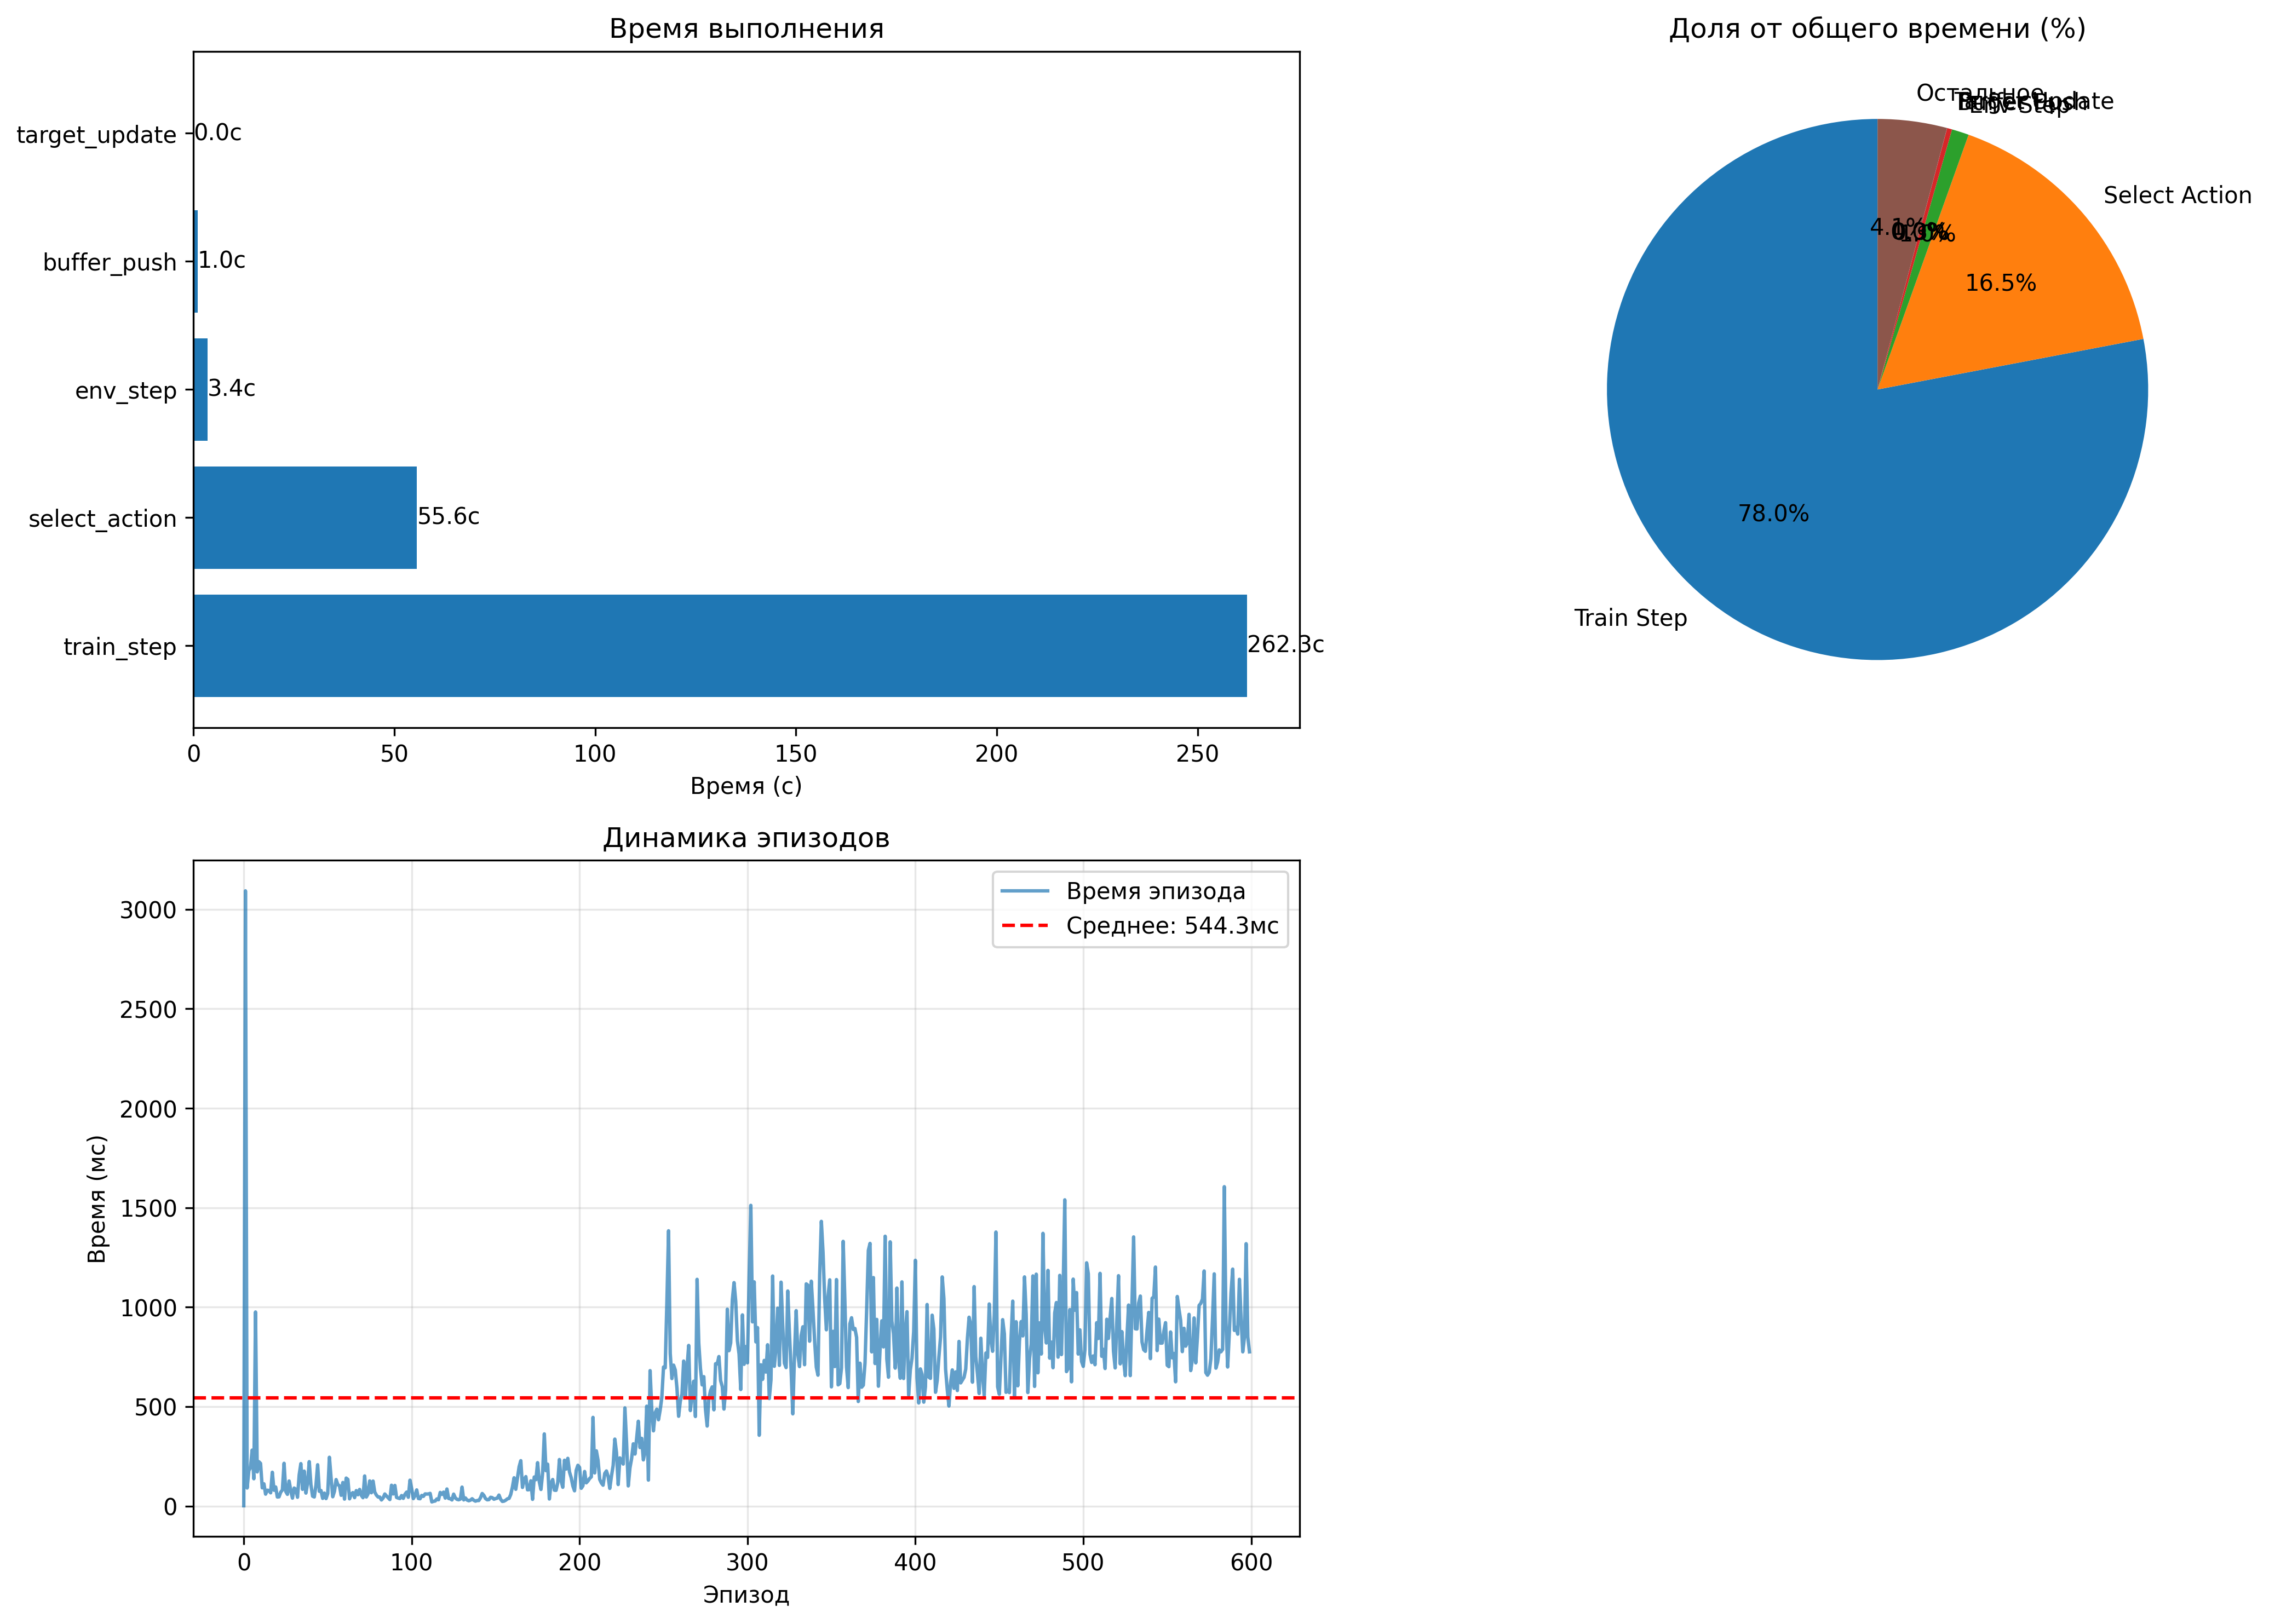

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

3. Select_action на CPU

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from numba import njit

@njit(cache=True, fastmath=True)
def jit_step(state, action):
    """state=[x,x_dot,theta,theta_dot] → new_state"""
    gravity = 9.81
    masscart = 1.0
    masspole = 0.1
    total_mass = 1.1
    length = 0.5
    polemass_length = 0.05
    force_mag = 10.0
    tau = 0.02

    x = state[0]; x_dot = state[1]; theta = state[2]; theta_dot = state[3]
    force = force_mag if action == 1 else -force_mag

    costheta = np.cos(theta)
    sintheta = np.sin(theta)
    temp = (force + polemass_length * theta_dot * theta_dot * sintheta) / total_mass
    thetaacc = (gravity * sintheta - costheta * temp) / (
        length * (4.0/3.0 - masspole * costheta * costheta / total_mass)
    )
    xacc = temp - polemass_length * thetaacc * costheta / total_mass

    state[0] = x + tau * x_dot
    state[1] = x_dot + tau * xacc
    state[2] = theta + tau * theta_dot
    state[3] = theta_dot + tau * thetaacc

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

        test = np.array([0.0, 0.0, 0.1, 0.0], dtype=np.float32)
        jit_step(test, 0)
        jit_step(test, 1)

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        action = int(action)
        jit_step(self.state, action)
        x, x_dot, theta, theta_dot = self.state
        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            #if self.steps_beyond_terminated == 0:
            #    print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return self.state.copy(), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,)).astype(np.float32)
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha

Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import cupy as cp
from cupy import RawKernel


seed = 40000
random.seed(seed)
np.random.seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.02   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 64  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 10  # 1-10 Частота обновления target network


k_td = RawKernel(r'''
extern "C" __global__
void td_grad_2a(const float* Q, const float* Qnext,
                const int* actions,
                const float* rewards,
                const float* dones,
                float gamma,
                float* dLdQ,     // [B,2]
                float* loss_out, // [B]
                int B) {
    int i = (int)(blockDim.x * blockIdx.x + threadIdx.x);
    if (i >= B) return;

    float q0 = Q[i*2 + 0];
    float q1 = Q[i*2 + 1];
    int a = actions[i] & 1;

    float q_sa = (a == 0) ? q0 : q1;

    float nq0 = Qnext[i*2 + 0];
    float nq1 = Qnext[i*2 + 1];
    float max_next = (nq0 > nq1) ? nq0 : nq1;

    float t = rewards[i] + (1.0f - dones[i]) * gamma * max_next;
    float diff = q_sa - t;

    // mean MSE: grad = 2*diff/B
    float g = 2.0f * diff / (float)B;

    dLdQ[i*2 + 0] = 0.0f;
    dLdQ[i*2 + 1] = 0.0f;
    dLdQ[i*2 + a] = g;

    loss_out[i] = diff * diff;
}
''', "td_grad_2a")


class DQN():
    def __init__(self, state_dim=4, h1=128, h2=128, action_dim=2, lr=2e-3, seed=40000):
        self.S, self.H1, self.H2, self.A = state_dim, h1, h2, action_dim
        self.lr = float(lr)
        cp.random.seed(seed)

        self.W1 = (cp.random.randn(self.S, self.H1).astype(cp.float32) * cp.float32(0.1))
        self.b1 = cp.zeros((self.H1,), dtype=cp.float32)
        self.W2 = (cp.random.randn(self.H1, self.H2).astype(cp.float32) * cp.float32(0.1))
        self.b2 = cp.zeros((self.H2,), dtype=cp.float32)
        self.W3 = (cp.random.randn(self.H2, self.A).astype(cp.float32) * cp.float32(0.1))
        self.b3 = cp.zeros((self.A,), dtype=cp.float32)

    def copy_from(self, other: "DQN"):
        self.W1 = other.W1.copy()
        self.b1 = other.b1.copy()
        self.W2 = other.W2.copy()
        self.b2 = other.b2.copy()
        self.W3 = other.W3.copy()
        self.b3 = other.b3.copy()

    @staticmethod
    def relu(x):
        return cp.maximum(x, cp.float32(0.0))

    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        H1 = self.relu(Z1)
        Z2 = H1 @ self.W2 + self.b2
        H2 = self.relu(Z2)
        Q  = H2 @ self.W3 + self.b3
        cache = (X, Z1, H1, Z2, H2)
        return Q, cache

    def train_step_cuda(self, target_net: "DQN",
                        states, actions, rewards, next_states, dones, gamma=0.99):
        B = int(states.shape[0])

        Q, cache = self.forward(states)
        with cp.cuda.Stream.null:
            Qnext, _ = target_net.forward(next_states)

        dLdQ = cp.empty((B, self.A), dtype=cp.float32)
        loss_vec = cp.empty((B,), dtype=cp.float32)

        threads = 256
        blocks = (B + threads - 1) // threads
        k_td((blocks,), (threads,),
             (Q, Qnext, actions, rewards, dones, cp.float32(gamma), dLdQ, loss_vec, B))

        X, Z1, H1, Z2, H2 = cache



        dW3 = H2.T @ dLdQ
        db3 = dLdQ.sum(axis=0)
        dH2 = dLdQ @ self.W3.T


        dZ2 = dH2 * (Z2 > 0)


        dW2 = H1.T @ dZ2
        db2 = dZ2.sum(axis=0)
        dH1 = dZ2 @ self.W2.T


        dZ1 = dH1 * (Z1 > 0)

        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0)

        lr = cp.float32(self.lr)
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.W2 -= lr * dW2; self.b2 -= lr * db2
        self.W3 -= lr * dW3; self.b3 -= lr * db3

        return loss_vec.mean()

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

class FastReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        # предварительная аллокация памяти
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        idx = self.ptr % self.capacity

        self.states[idx] = state
        self.actions[idx] = action
        self.rewards[idx] = reward
        self.next_states[idx] = next_state
        self.dones[idx] = done

        self.ptr += 1
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        # векторизированные индексы
        idxs = np.random.randint(0, self.size, size=batch_size)

        return (
            self.states[idxs],
            self.actions[idxs],
            self.rewards[idxs],
            self.next_states[idxs],
            self.dones[idxs]
        )

    def __len__(self):
        return self.size

# Выбор действия
def select_action(state, epsilon, action_dim, W1, b1, W2, b2, W3, b3):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)

    x = state.astype(np.float32, copy=False)[None, :]  # [1,4]
    z1 = x @ W1 + b1
    h1 = np.maximum(z1, 0.0)
    z2 = h1 @ W2 + b2
    h2 = np.maximum(z2, 0.0)
    q  = h2 @ W3 + b3  # [1,2]
    return int(np.argmax(q, axis=1)[0])

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)


    states      = cp.asarray(states, dtype=cp.float32)
    next_states = cp.asarray(next_states, dtype=cp.float32)
    actions     = cp.asarray(actions, dtype=cp.int32)
    rewards     = cp.asarray(rewards, dtype=cp.float32)
    dones       = cp.asarray(dones, dtype=cp.float32)

    loss = policy_net.train_step_cuda(target_net, states, actions, rewards, next_states, dones, gamma=gamma)
    return float(loss.get())

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)

        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2  # MB
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)       # CPU%

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }


profiler = Profiler()


# Основной код
if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    #env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, 128, 128, action_dim, lr=LR, seed=seed)
    target_net = DQN(state_dim, 128, 128, action_dim, lr=LR, seed=seed)
    target_net.copy_from(policy_net)
    optimizer = None
    # CPU копии весов
    W1_cpu = cp.asnumpy(policy_net.W1)
    b1_cpu = cp.asnumpy(policy_net.b1)
    W2_cpu = cp.asnumpy(policy_net.W2)
    b2_cpu = cp.asnumpy(policy_net.b2)
    W3_cpu = cp.asnumpy(policy_net.W3)
    b3_cpu = cp.asnumpy(policy_net.b3)

    # replay_buffer = ReplayBuffer(MEMORY_SIZE)
    replay_buffer = FastReplayBuffer(MEMORY_SIZE, state_dim, 1)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, action_dim,
                           W1_cpu, b1_cpu, W2_cpu, b2_cpu, W3_cpu, b3_cpu)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.copy_from(policy_net)
            profiler.stop('target_update')
            W1_cpu = cp.asnumpy(policy_net.W1); b1_cpu = cp.asnumpy(policy_net.b1)
            W2_cpu = cp.asnumpy(policy_net.W2); b2_cpu = cp.asnumpy(policy_net.b2)
            W3_cpu = cp.asnumpy(policy_net.W3); b3_cpu = cp.asnumpy(policy_net.b3)
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    np.savez('dqn_model_cupy.npz',
            W1=cp.asnumpy(policy_net.W1), b1=cp.asnumpy(policy_net.b1),
            W2=cp.asnumpy(policy_net.W2), b2=cp.asnumpy(policy_net.b2),
            W3=cp.asnumpy(policy_net.W3), b3=cp.asnumpy(policy_net.b3))

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
%%writefile RL/run_catpole_DQN.py

import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import sys
import os
import numpy as np
import imageio
from pyvirtualdisplay import Display
import cupy as cp

project_root = os.path.dirname(os.path.abspath(__file__))
sys.path.append(project_root)

from gymnasium_env_RL.envs.cartpole_DQN_train import DQN  # твой CuPy DQN

gif_filename = 'cartpole_test_DQN.gif'
fps = 15

ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
STATE_DIM = 4
ACTION_DIM = 2
MAX_STEPS = 500

#CuPy сеть
policy_net = DQN(state_dim=STATE_DIM, h1=128, h2=128, action_dim=ACTION_DIM, lr=0.0)

# Загружаем веса
ckpt = np.load('dqn_model_cupy.npz')
policy_net.W1 = cp.asarray(ckpt['W1'], dtype=cp.float32)
policy_net.b1 = cp.asarray(ckpt['b1'], dtype=cp.float32)
policy_net.W2 = cp.asarray(ckpt['W2'], dtype=cp.float32)
policy_net.b2 = cp.asarray(ckpt['b2'], dtype=cp.float32)
policy_net.W3 = cp.asarray(ckpt['W3'], dtype=cp.float32)
policy_net.b3 = cp.asarray(ckpt['b3'], dtype=cp.float32)
W1_cpu = ckpt['W1'].astype(np.float32); b1_cpu = ckpt['b1'].astype(np.float32)
W2_cpu = ckpt['W2'].astype(np.float32); b2_cpu = ckpt['b2'].astype(np.float32)
W3_cpu = ckpt['W3'].astype(np.float32); b3_cpu = ckpt['b3'].astype(np.float32)

print("CuPy модель загружена из dqn_model_cupy.npz")


env = gym.make(ENV_NAME, render_mode='rgb_array')


def select_action(state):
    x = state.astype(np.float32, copy=False)[None, :]  # [1,4]
    z1 = x @ W1_cpu + b1_cpu
    h1 = np.maximum(z1, 0.0)
    z2 = h1 @ W2_cpu + b2_cpu
    h2 = np.maximum(z2, 0.0)
    q  = h2 @ W3_cpu + b3_cpu
    return int(np.argmax(q, axis=1)[0])

with Display(visible=0, size=(400, 300)):
    NUM_EVAL_EPISODES = 10
    rewards = []
    all_frames = []

    for episode in range(NUM_EVAL_EPISODES):
        state, _ = env.reset()
        total_reward = 0.0
        done = False
        step_count = 0

        while not done and step_count < MAX_STEPS:
            action = select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated
            state = next_state
            total_reward += float(reward)
            step_count += 1

            img = env.render()
            if isinstance(img, np.ndarray):
                all_frames.append(img[:, :, :3])

        rewards.append(total_reward)
        print(f"Оценка эпизода {episode + 1}: Награда = {total_reward}")

    mean_reward = sum(rewards) / len(rewards)
    print(f"Средняя награда за {NUM_EVAL_EPISODES} эпизодов: {mean_reward:.2f}")

    imageio.mimsave(gif_filename, all_frames, fps=fps)
    print(f"GIF сохранён: {gif_filename}")

env.close()


Overwriting RL_course_2/run_catpole_DQN.py


In [ ]:
%%writefile RL/run_env.py

import gymnasium_env_RL
import gymnasium as gym
import imageio
import os

OUTPUT_DIR = '/content/RL'
GIF_FILENAME = 'cartpole_test.gif' # имя GIF

env_id = 'gymnasium_env_RL/CartPoleEnv-v0'
num_steps = 100
render_mode = 'rgb_array'

gif_save_path = os.path.join(OUTPUT_DIR, GIF_FILENAME)

env = gym.make('gymnasium_env_RL/CartPoleEnv-v0', render_mode=render_mode)

obs, info = env.reset()
total_reward = 0
all_frames = []

for step in range(num_steps):
    # action = env.action_space.sample() # рандомное действие
    action = int(input("Action (0=left, 1=right): ")) # 0 - влево, 1 - вправо

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    frame = env.render()
    all_frames.append(frame)

    if terminated or truncated:
        print(f"Эпизод завершен, общая награда: {total_reward}")
        break

env.close()

if all_frames:
    imageio.mimsave(gif_save_path, all_frames, duration=0.05, loop=0)
    print(f"GIF сохранен: {gif_save_path}")

Overwriting RL_course_2/run_env.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-f_mtr5ad/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:521: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 12.0, Epsilon: 0.985
Episode 4/600, Reward: 18.0, Epsilon: 0.980
Episode 5/600, Reward: 18.0, Epsilon: 0.975
Episode 6/600, Reward: 28.0, Epsilon: 0.970
Episode 7/600, Reward: 21.0, Epsilon: 0.966
Episode 8/60

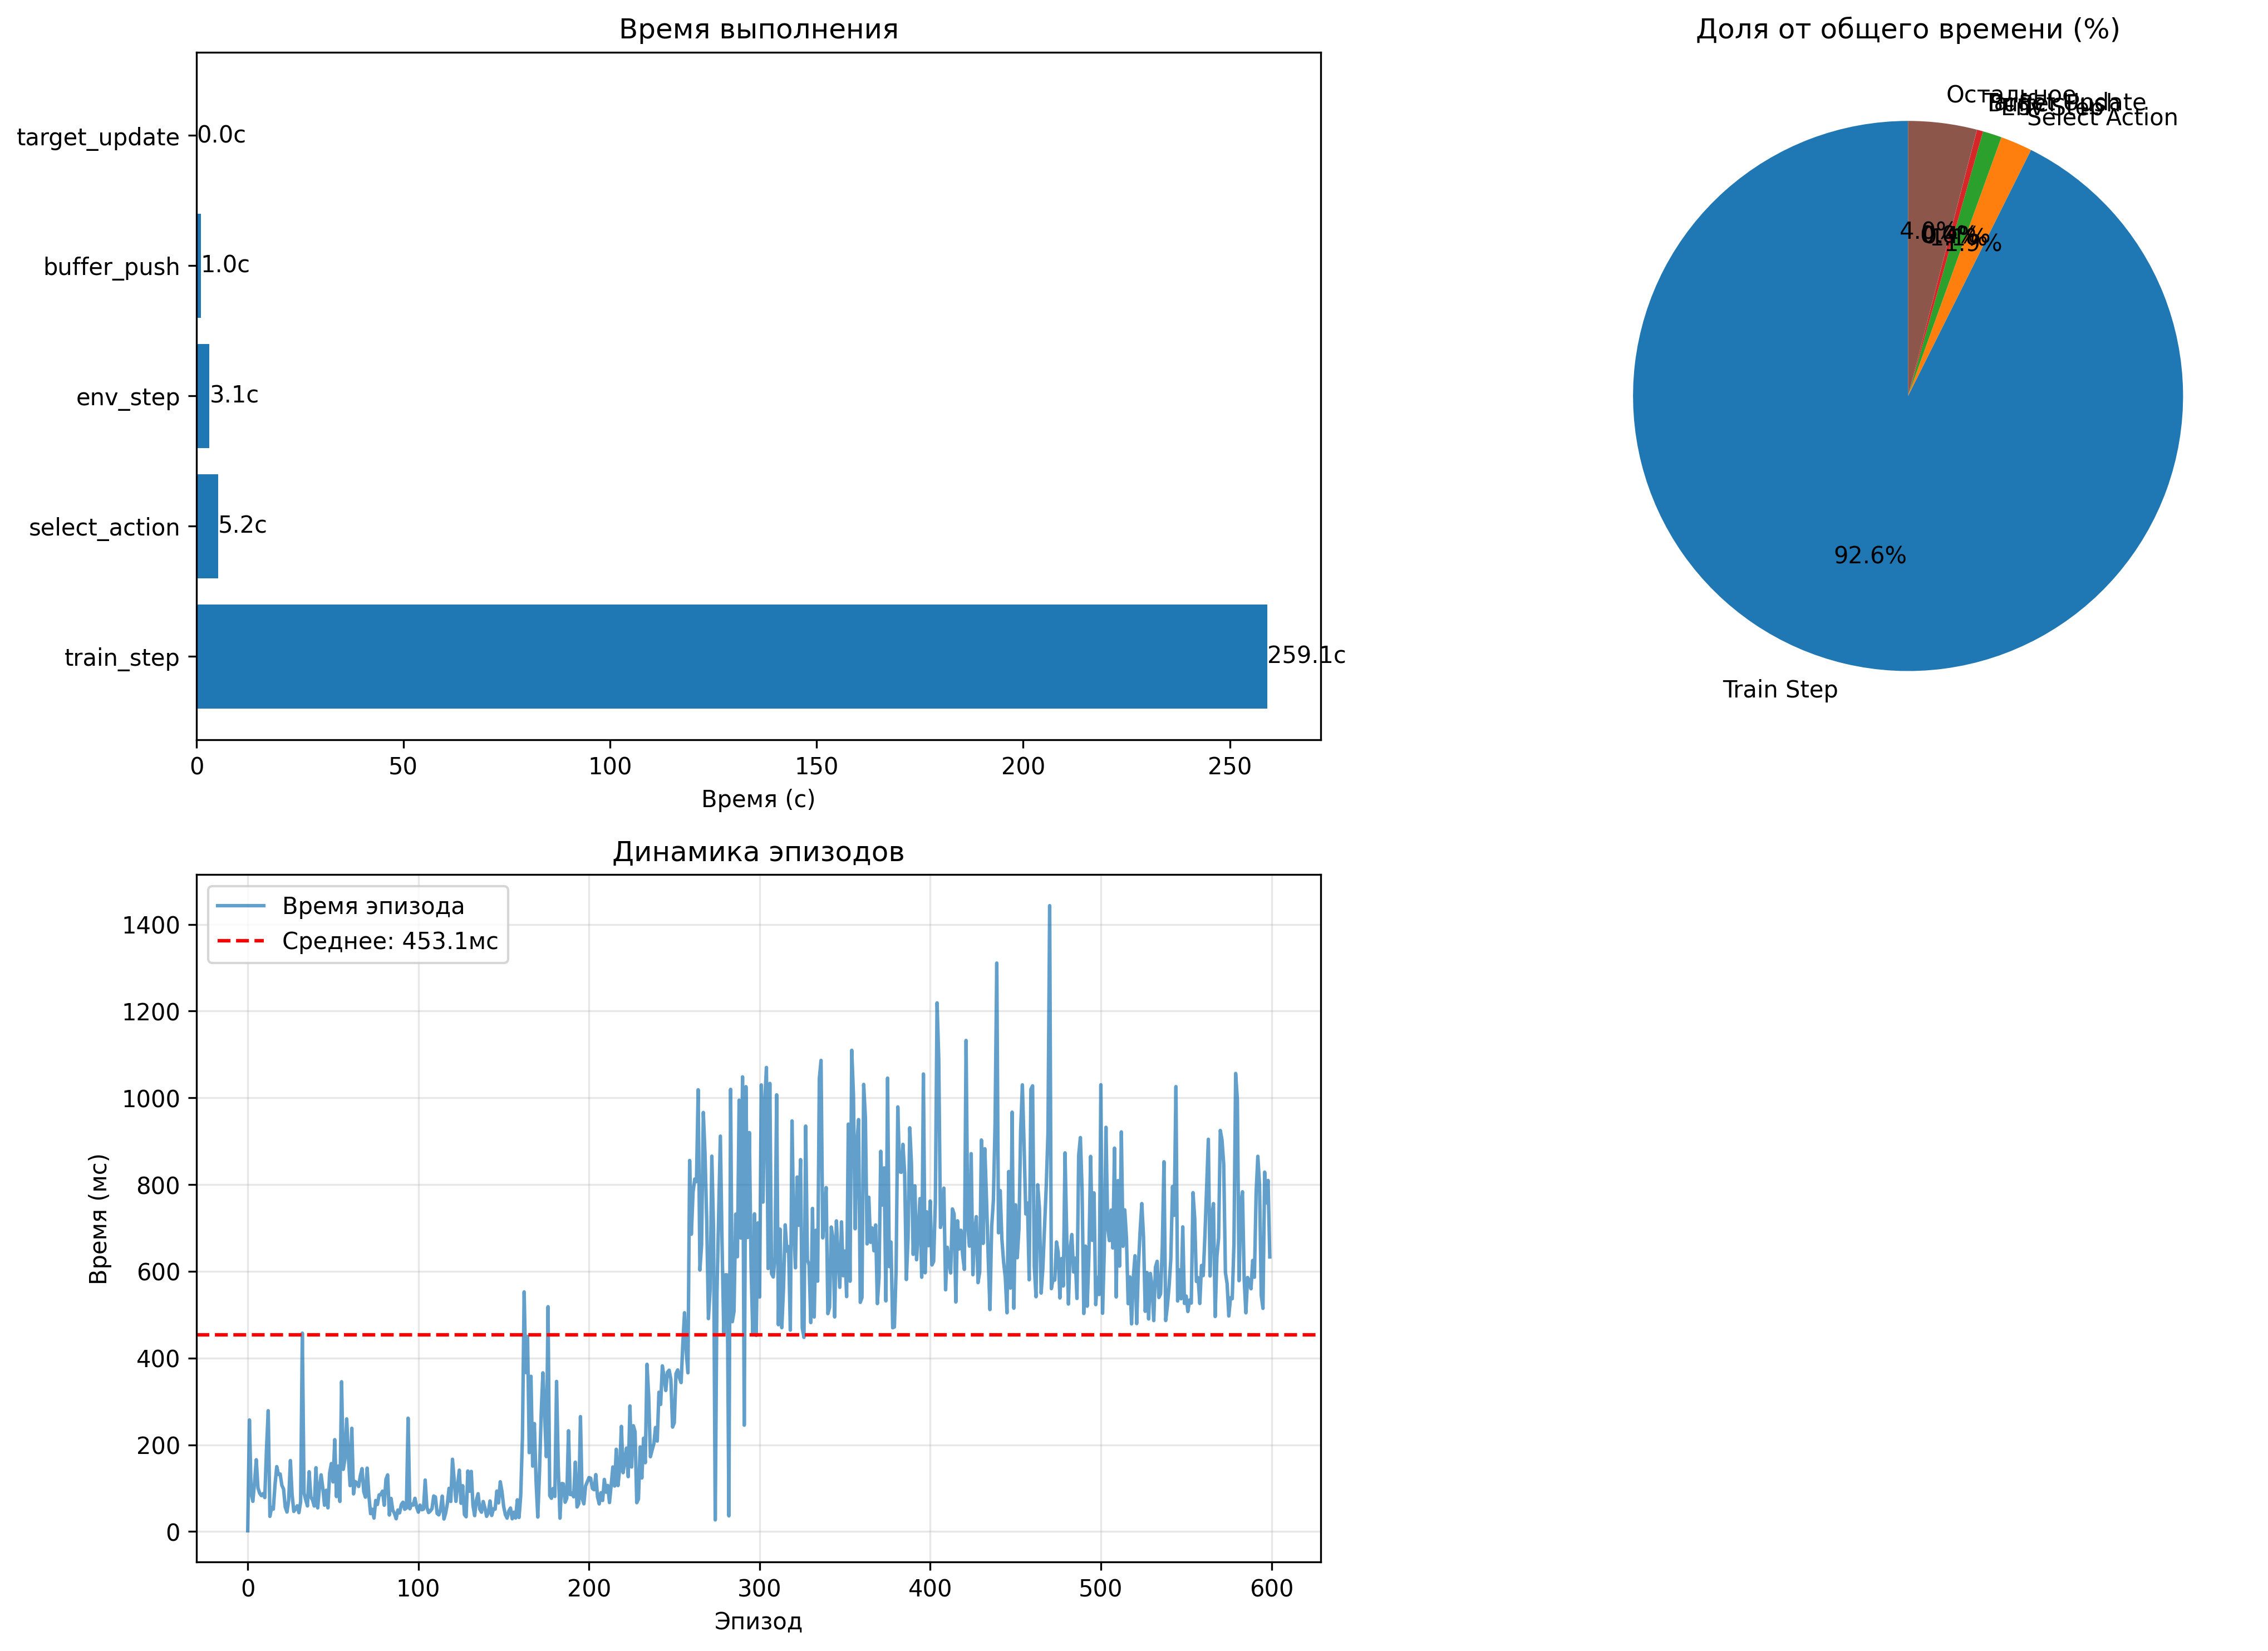

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        # Параметры среды (идентичны CartPole-v1)
        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        x, x_dot, theta, theta_dot = self.state # извлечение текущего состояния

        # Наше действие - толкаем тележку право или влево
        force = self.force_mag if action == 1 else -self.force_mag

        # Физика среды (обратный маятник)
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        temp = (force + self.polemass_length * theta_dot * theta_dot * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (self.length * (4.0/3.0 - self.masspole * costheta * costheta / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == 'euler': # расчёт нового состояния
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot) # обновление состояния

        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            if self.steps_beyond_terminated == 0:
                print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return np.array(self.state, dtype=np.float32), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import time
import psutil
import os
from typing import Dict
import pandas as pd


seed = 40000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Параметры
# ENV_NAME = 'CartPole-v1'
ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
EPISODES = 600  # > 200 Количество эпизодов обучения
MAX_STEPS = 500  # 200-1000 Лимит шагов в эпизоде
GAMMA = 0.99  # 0.9-0.999 Коэффициент дисконтирования
EPSILON_START = 1.0  # 0.8-1 Начальный epsilon
EPSILON_END = 0.02   # 0.001-0.05 Минимальный epsilon
EPSILON_DECAY = 0.995  # 0.9-0.999 Уменьшение epsilon
BATCH_SIZE = 64  # 32-256 Размер батча
LR = 0.001  # 0.0001-0.005 Скорость обучения
MEMORY_SIZE = 50000  # 10000-100000, Размер replay buffer
TARGET_UPDATE = 10  # 1-10 Частота обновления target network

# Определяем Q-сеть (нейросеть - аппроксиматор Q функции)
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Буфер
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity) # очередь фикс размера

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

class FastReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        # предварительная аллокация памяти
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        idx = self.ptr % self.capacity

        self.states[idx] = state
        self.actions[idx] = action
        self.rewards[idx] = reward
        self.next_states[idx] = next_state
        self.dones[idx] = done

        self.ptr += 1
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        # векторизированные индексы
        idxs = np.random.randint(0, self.size, size=batch_size)

        return (
            self.states[idxs],
            self.actions[idxs],
            self.rewards[idxs],
            self.next_states[idxs],
            self.dones[idxs]
        )

    def __len__(self):
        return self.size

# Выбор действия
def select_action(state, epsilon, policy_net, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1) # случайное действие с вероятностью epsilon
    else:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0)
            q_values = policy_net(state)
            return q_values.argmax().item() # действие с максимальным Q

# Обучение
def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size: # достаточно ли данных
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    # Преобразование в тензоры
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    # Вычисляем Q-values для текущих состояний и отбираем те которые соотв действиям агента
    q_values = policy_net(states).gather(1, actions)

    # Q-values для следующих состояний (используем target_net)
    next_q_values = target_net(next_states).max(1, keepdim=True)[0]
    target_q_values = rewards + (1 - dones) * gamma * next_q_values

    # Loss и обновление весов
    loss = nn.MSELoss()(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

class Metrics:
    def __init__(self, component: str):
        self.component = component  # str

        self.data = np.array([
            0,                          # calls: int
            0.0,                        # total_time: float
            np.inf,                     # min_time: float
            0.0,                        # max_time: float
            0.0                         # avg_time_ms: float
        ], dtype=np.float64)
        self._start = 0.0

    @property
    def calls(self) -> int:
        return int(self.data[0])

    @calls.setter
    def calls(self, value: int):
        self.data[0] = float(value)

    @property
    def total_time(self) -> float:
        return self.data[1]

    @total_time.setter
    def total_time(self, value: float):
        self.data[1] = value

    @property
    def min_time(self) -> float:
        return self.data[2]

    @min_time.setter
    def min_time(self, value: float):
        self.data[2] = value

    @property
    def max_time(self) -> float:
        return self.data[3]

    @max_time.setter
    def max_time(self, value: float):
        self.data[3] = value

    @property
    def avg_time_ms(self) -> float:
        return self.data[4]

    @avg_time_ms.setter
    def avg_time_ms(self, value: float):
        self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start

        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls


class Profiler:
    def __init__(self, max_episodes: int = 1000):
        self.metrics: Dict[str, Metrics] = {}
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0
    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        self.episode_times[self.episode_idx] = elapsed

        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(0.01)

        self.episode_idx += 1

    def snapshot_system(self):
        process = psutil.Process(os.getpid())
        self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2  # MB
        self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=0.01)       # CPU%

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start

        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }

profiler = Profiler()



if __name__ == "__main__":
    env = gym.make(ENV_NAME) # создание среды
    normalizaton = 'Off'
    # env, normalizaton = NormalizeObservation(env), 'On' # Включение нормализации

    state_dim = env.observation_space.shape[0] # инициализация состояния
    action_dim = env.action_space.n # инициализация действия

    policy_net = DQN(state_dim, action_dim) # инициализация сетей
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    # replay_buffer = ReplayBuffer(MEMORY_SIZE)
    replay_buffer = FastReplayBuffer(MEMORY_SIZE, state_dim, 1)

    epsilon = EPSILON_START # сброс
    rewards_history = []

    # В каждом эпизоде:
    for episode in range(EPISODES):
        profiler.episode_start()
        state, _ = env.reset() # сброс
        total_reward = 0

        # Среда рассчитывается до завершения эпизода:
        for step in range(MAX_STEPS):
            profiler.start('select_action')
            action = select_action(state, epsilon, policy_net, action_dim)
            profiler.stop('select_action')
            profiler.start('env_step')
            next_state, reward, terminated, truncated, _ = env.step(action)
            profiler.stop('env_step')
            done = terminated or truncated # терминальное состояние или завершение по времени

            profiler.start('buffer_push')
            replay_buffer.push(state, action, reward, next_state, done)
            profiler.stop('buffer_push')

            profiler.start('train_step')
            train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
            profiler.stop('train_step')

            state = next_state
            total_reward += reward

            if done:
                break

        profiler.episode_end()

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Обновление target network
        if episode % TARGET_UPDATE == 0:
            profiler.start('target_update')
            target_net.load_state_dict(policy_net.state_dict())
            profiler.stop('target_update')
        rewards_history.append(total_reward)
        print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")
    env.close()


    stats = profiler.get_stats()
    total_runtime = stats['total_runtime']
    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    metrics_sorted = sorted(stats['metrics'], key=lambda x: x['total_time'], reverse=True)
    for m in metrics_sorted:
        pct = m['pct_total']
        print(f"{m['name']:<15} | {m['calls']:>8,} | "
              f"{m['avg_time_ms']:>6.2f}мс | {m['total_time']:>6.1f}с | {pct:>5.1f}%")
    print(f"Эпизоды: {stats['episode_times_ms'].mean():.1f}±{stats['episode_times_ms'].std():.1f}мс")
    print(f"RAM: {stats['memory_usage_mb'].max():.0f}MB | CPU: {stats['cpu_usage_pct'].mean():.0f}%")

    print(f"\nReplayBuffer: {len(replay_buffer):,} / {MEMORY_SIZE:,} ({len(replay_buffer)/MEMORY_SIZE*100:.1f}%)")


    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)

    pct_values = [m['pct_total'] for m in metrics_sorted]
    pct_values.append(100 - sum(pct_values))  # Остальное!
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]
    labels_pie.append('Остальное')  # env.reset(), графики...

    wedges, texts, autotexts = ax2.pie([m['total_time'] for m in metrics_sorted] + [total_runtime - sum(times_abs)],
                                    labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    episode_times_ms = stats['episode_times_ms']
    ax3.plot(episode_times_ms[:EPISODES], alpha=0.7, label='Время эпизода')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.1f}мс')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Динамика эпизодов')

    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Сохранение модели
    torch.save({
        'policy_net_state_dict': policy_net.state_dict(),
        'state_dim': state_dim,
        'action_dim': action_dim,
        # Опционально:
        # 'epsilon': epsilon,
        # 'GAMMA': GAMMA,
        # 'LR': LR
    }, 'dqn_model.pth')  # Сохраняет в файл dqn_model.pth

    # Графики обучения
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, linewidth=1.25, color='b')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.grid(True)
    plt.savefig('training_DQN.png', dpi=300)
    # plt.show()

    # Скользящее среднее для сглаживания графика
    window_size = 25
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(10, 5))
        plt.plot(rewards_history, linewidth=1, color='b', alpha=0.5)
        plt.plot(moving_avg, linewidth=2, color='b')
        plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        plt.savefig('training_DQN_RunMean.png', dpi=300)
        plt.close()


Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-1odj084r/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/content/RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py:421: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'Скользящее среднее наград (M = {window_size}),\n$\\gamma = ${GAMMA}, $\\epsilon_d$ = {EPSILON_DECAY}, $learning\ rate = ${LR}, Normalization = {normalizaton}, seed = {seed}')
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Episode 1/600, Reward: 14.0, Epsilon: 0.995
Episode 2/600, Reward: 56.0, Epsilon: 0.990
Episode 3/600, Reward: 12.0, Epsilon: 0.985
Episode 4/600, Reward: 18.0, Epsilon: 0.980
Episode 5/600, Reward: 18.0, Epsilon: 0.975
Episode 6/600, Reward: 28.0, Epsilon: 0.970
Episode 7/600, Reward: 21.0, Epsilon: 0.966
Episode 8/60

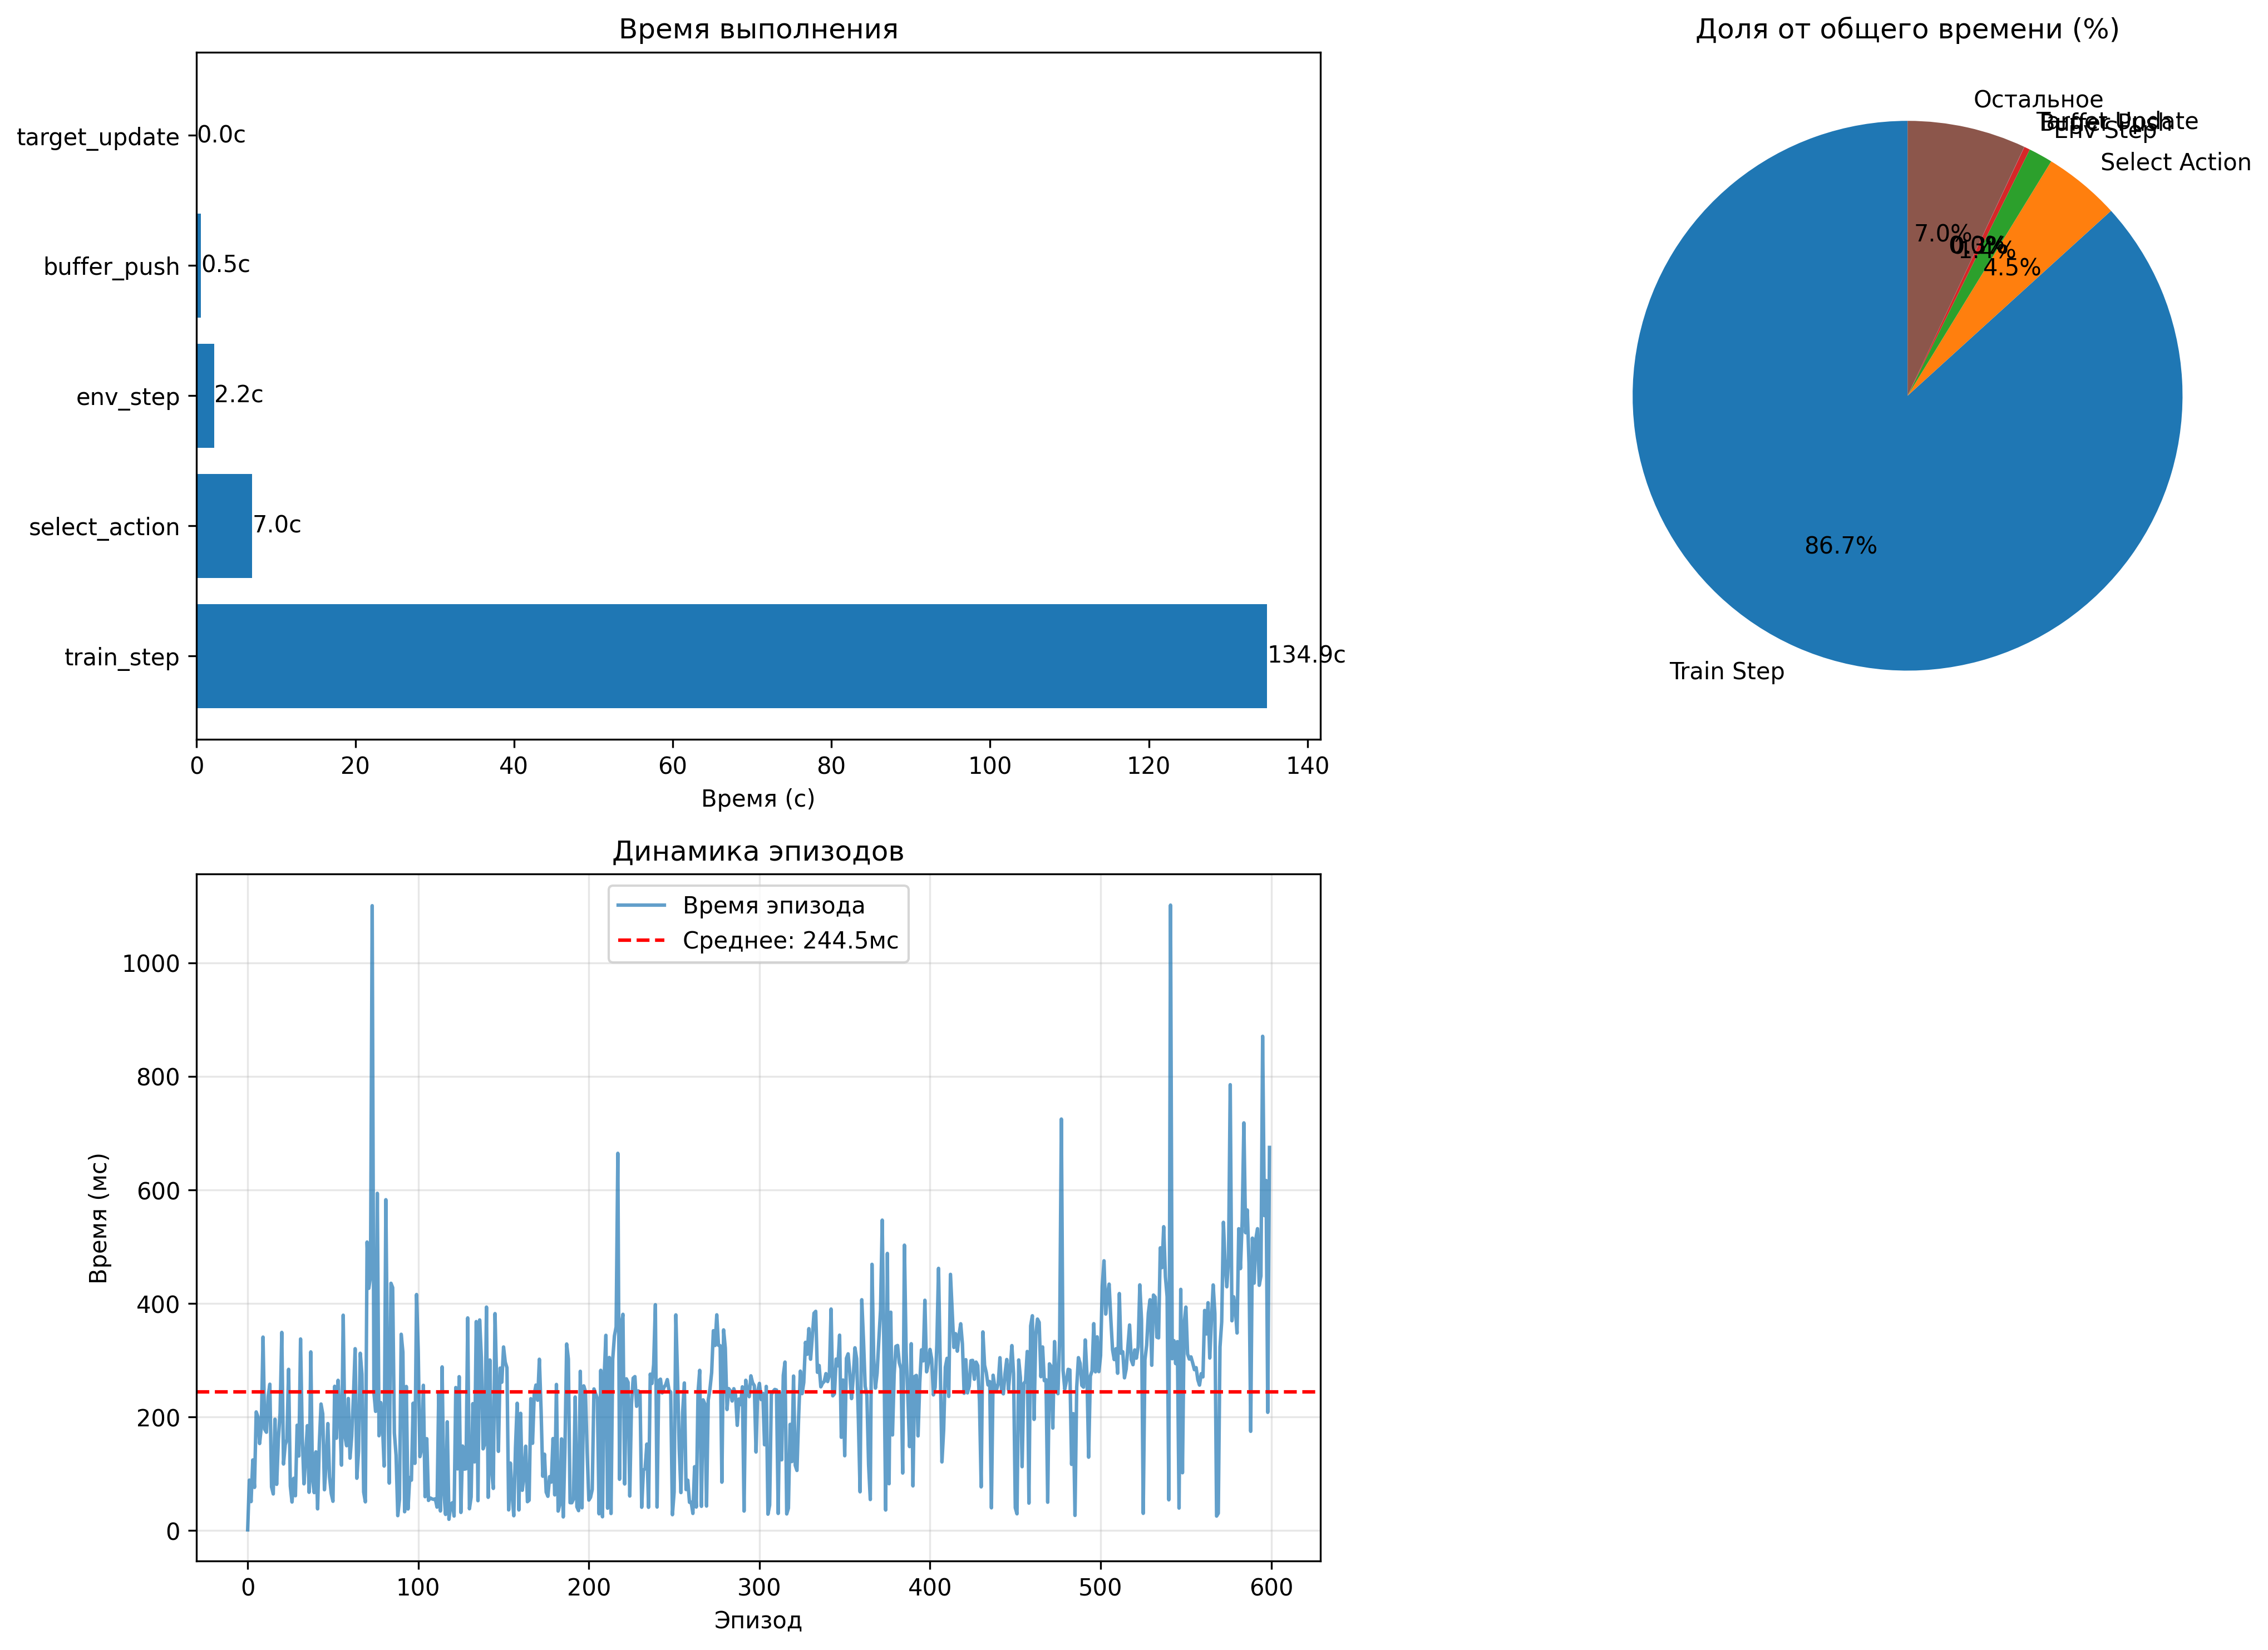

In [ ]:
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")

---
Параллелизация

In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_env.py

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from numba import njit

@njit(cache=True, fastmath=True)
def jit_step(state, action):
    gravity = 9.81
    masscart = 1.0
    masspole = 0.1
    total_mass = 1.1
    length = 0.5
    polemass_length = 0.05
    force_mag = 10.0
    tau = 0.02

    x = state[0]; x_dot = state[1]; theta = state[2]; theta_dot = state[3]
    force = force_mag if action == 1 else -force_mag

    costheta = np.cos(theta)
    sintheta = np.sin(theta)
    temp = (force + polemass_length * theta_dot * theta_dot * sintheta) / total_mass
    thetaacc = (gravity * sintheta - costheta * temp) / (
        length * (4.0/3.0 - masspole * costheta * costheta / total_mass)
    )
    xacc = temp - polemass_length * thetaacc * costheta / total_mass

    state[0] = x + tau * x_dot
    state[1] = x_dot + tau * xacc
    state[2] = theta + tau * theta_dot
    state[3] = theta_dot + tau * thetaacc

class CartPoleEnv(gym.Env): # наследуем от базового класса Gymnasium
    """
    Кастомная среда CartPole (обратный маятник).
    Идентична CartPole-v1 (Gymnasium)
    """
    metadata = {"render_modes": ["human", "rgb_array"], 'render_fps': 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode

        self.gravity = 9.81     # Ускорение свободного падения
        self.masscart = 1.0     # Масса тележки (cart)
        self.masspole = 0.1     # Масса палки (pole)
        self.total_mass = self.masspole + self.masscart # Общая масса маятника
        self.length = 0.5       # Половина длины палки (центр масс в середине)
        self.polemass_length = self.masspole * self.length # Момент инерции палки
        self.force_mag = 10.0   # Сила, с которой мы толкаем тележку
        self.tau = 0.02         # Шаг времени (dt, дискретизация среды)
        self.kinematics_integrator = 'euler' # Метод аппроксимации производных

        # Границы состояний (переход в терминальное состояние)
        self.x_threshold = 2.4  # граница по горизонтальной оси
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 12 градусов (в рад)

        # Пространства
        self.action_space = spaces.Discrete(2)  # дискретное для действий (0 влево, 1 вправо)
        self.observation_space = spaces.Box(    # непрерывное для состяния (в 2 раза больше для стабильности)
            low=np.array([-self.x_threshold * 2, -np.inf, -self.theta_threshold_radians * 2, -np.inf]),
            high=np.array([self.x_threshold * 2, np.inf, self.theta_threshold_radians * 2, np.inf]),
            # dtype=np.float32
        )

        # Внутреннее состояние
        self.state = None
        self.steps_beyond_terminated = None

        test = np.array([0.0, 0.0, 0.1, 0.0], dtype=np.float32)
        jit_step(test, 0)
        jit_step(test, 1)

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}" # действие корректно
        assert self.state is not None, "Call reset() before step()" # состояние инициализировано

        action = int(action)
        jit_step(self.state, action)
        x, x_dot, theta, theta_dot = self.state
        # Проверка терминального состояния
        terminated = bool(
            x < -self.x_threshold or x > self.x_threshold or
            theta < -self.theta_threshold_radians or theta > self.theta_threshold_radians
        )

        # Награда: +1 за каждый шаг пока эпизод не завершен
        if not terminated:
            reward = 1.0
        elif self.steps_beyond_terminated is None:
            self.steps_beyond_terminated = 0
            reward = 1.0
        else:
            #if self.steps_beyond_terminated == 0:
            #    print("Episode terminated!")
            self.steps_beyond_terminated += 1
            reward = 0.0

        truncated = False  # без лимита шагов

        return self.state.copy(), reward, terminated, truncated, {}

    def reset(self, seed=None, options=None): # сброс среды
        super().reset(seed=seed)
        # Инициализация близко к центру
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,)).astype(np.float32)
        self.steps_beyond_terminated = None
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"): # для визуализации
        if self.render_mode == "rgb_array":
            return self._render_rgb_array()
        else:
            self._render_human()

    def _render_human(self):
        # Вывод положения в консоль
        x, _, theta, _ = self.state
        print(f"Cart position: {x:.2f}, Pole angle: {theta:.2f} rad")

    def _render_rgb_array(self):
        # Визуализация через matplotlib
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.clear()

        ax.set_xlim(-self.x_threshold, self.x_threshold) # границы
        ax.set_ylim(-0.7, 0.7)
        ax.axis('off') # убираем оси

        # Тележка (влияет только на визуализацию, как и все в этой функции)
        cart_width, cart_height = 0.4, 0.1
        cart = Rectangle((self.state[0] - cart_width/2, -cart_height/2), cart_width, cart_height, color='blue')
        ax.add_patch(cart)

        # Палка
        pole_x = self.state[0]
        pole_y = 0
        pole_end_x = pole_x + self.length * np.sin(self.state[2])
        pole_end_y = pole_y + self.length * np.cos(self.state[2])
        ax.plot([pole_x, pole_end_x], [pole_y, pole_end_y], 'r-', linewidth=3)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img[:, :, :3]  # RGB без alpha

Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_env.py


In [ ]:
%%writefile RL/gymnasium_env_RL/envs/cartpole_DQN_train.py

import gymnasium as gym
import gymnasium_env_RL
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import time
import psutil
import os
import matplotlib.pyplot as plt
from typing import Dict

class Metrics:
    def __init__(self, component: str):
        self.component = component
        self.data = np.array([0, 0.0, np.inf, 0.0, 0.0], dtype=np.float64) # calls, total, min, max, avg
        self._start = 0.0

    @property
    def calls(self) -> int: return int(self.data[0])
    @calls.setter
    def calls(self, value: int): self.data[0] = float(value)

    @property
    def total_time(self) -> float: return self.data[1]
    @total_time.setter
    def total_time(self, value: float): self.data[1] = value

    @property
    def min_time(self) -> float: return self.data[2]
    @min_time.setter
    def min_time(self, value: float): self.data[2] = value

    @property
    def max_time(self) -> float: return self.data[3]
    @max_time.setter
    def max_time(self, value: float): self.data[3] = value

    @property
    def avg_time_ms(self) -> float: return self.data[4]
    @avg_time_ms.setter
    def avg_time_ms(self, value: float): self.data[4] = value

    def start(self):
        self._start = time.perf_counter()

    def stop(self):
        elapsed = time.perf_counter() - self._start
        self.calls += 1
        self.total_time += elapsed
        self.min_time = min(self.min_time, elapsed)
        self.max_time = max(self.max_time, elapsed)
        self.avg_time_ms = self.total_time * 1000 / self.calls

class Profiler:
    def __init__(self, max_episodes: int = 200000):
        self.metrics: Dict[str, Metrics] = {}
        #с запасом под векторные шаги
        self.episode_times = np.zeros(max_episodes, dtype=np.float64)
        self.memory_usage = np.zeros(max_episodes, dtype=np.float64)
        self.cpu_usage = np.zeros(max_episodes, dtype=np.float64)
        self.global_start = time.perf_counter()
        self.episode_start_time = 0.0
        self.episode_idx = 0

    def start(self, name: str):
        if name not in self.metrics:
            self.metrics[name] = Metrics(name)
        self.metrics[name].start()

    def stop(self, name: str):
        self.metrics[name].stop()

    def episode_start(self):
        self.episode_start_time = time.perf_counter()

    def episode_end(self):
        elapsed = time.perf_counter() - self.episode_start_time
        if self.episode_idx < len(self.episode_times):
            self.episode_times[self.episode_idx] = elapsed

            #interval=None чтобы не блокировать выполнение каждого измерение
            process = psutil.Process(os.getpid())
            self.memory_usage[self.episode_idx] = process.memory_info().rss / 1024**2
            self.cpu_usage[self.episode_idx] = psutil.cpu_percent(interval=None)

            self.episode_idx += 1

    def get_stats(self):
        total_runtime = time.perf_counter() - self.global_start
        metrics_data = []
        for name, metric in self.metrics.items():
            metrics_data.append({
                'name': name,
                'calls': metric.calls,
                'total_time': metric.total_time,
                'avg_time_ms': metric.avg_time_ms,
                'min_time_ms': metric.min_time * 1000,
                'max_time_ms': metric.max_time * 1000,
                'pct_total': metric.total_time / total_runtime * 100
            })

        metrics_data.sort(key=lambda x: x['total_time'], reverse=True)

        return {
            'total_runtime': total_runtime,
            'metrics': metrics_data,
            'episode_times_ms': self.episode_times[:self.episode_idx] * 1000,
            'memory_usage_mb': self.memory_usage[:self.episode_idx],
            'cpu_usage_pct': self.cpu_usage[:self.episode_idx]
        }


# Параметры
seed = 40000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
NUM_ENVS = 16
TOTAL_TIMESTEPS = 200000
BATCH_SIZE = 128
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.02
EPSILON_DECAY = 0.995
LR = 0.001
MEMORY_SIZE = 50000
TARGET_UPDATE = 10

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class FastReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def push_batch(self, states, actions, rewards, next_states, dones):
        num_samples = states.shape[0]
        idxs = np.arange(self.ptr, self.ptr + num_samples) % self.capacity
        self.states[idxs] = states
        self.actions[idxs] = actions.reshape(-1, 1)
        self.rewards[idxs] = rewards.reshape(-1, 1)
        self.next_states[idxs] = next_states
        self.dones[idxs] = dones.reshape(-1, 1)
        self.ptr = (self.ptr + num_samples) % self.capacity
        self.size = min(self.size + num_samples, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (self.states[idxs], self.actions[idxs], self.rewards[idxs],
                self.next_states[idxs], self.dones[idxs])
    def __len__(self): return self.size

def select_action_vectorized(states, epsilon, policy_net, action_dim, num_envs):
    actions = np.zeros(num_envs, dtype=np.int64)
    random_mask = np.random.random(num_envs) < epsilon
    if random_mask.any():
        actions[random_mask] = np.random.randint(0, action_dim, size=random_mask.sum())
    if (~random_mask).any():
        with torch.no_grad():
            states_tensor = torch.FloatTensor(states[~random_mask])
            q_values = policy_net(states_tensor)
            actions[~random_mask] = q_values.argmax(dim=1).cpu().numpy()
    return actions

def train_step(policy_net, target_net, optimizer, replay_buffer, batch_size, gamma):
    if len(replay_buffer) < batch_size: return
    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)
    q_values = policy_net(states).gather(1, actions)
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1, keepdim=True)[0]
        target_q_values = rewards + (1 - dones) * gamma * next_q_values
    loss = nn.MSELoss()(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()


if __name__ == "__main__":
    max_loops = int(TOTAL_TIMESTEPS / NUM_ENVS) + 100
    profiler = Profiler(max_episodes=max_loops)

    envs = gym.make_vec(ENV_NAME, num_envs=NUM_ENVS, vectorization_mode='sync')
    #трекинг наград для лога
    envs = gym.wrappers.vector.RecordEpisodeStatistics(envs)

    state_dim = envs.observation_space.shape[1]
    action_dim = envs.action_space[0].n

    policy_net = DQN(state_dim, action_dim)
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()
    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    replay_buffer = FastReplayBuffer(MEMORY_SIZE, state_dim, 1)

    epsilon = EPSILON_START
    states, _ = envs.reset(seed=seed)

    global_step = 0

    from tqdm import tqdm
    pbar = tqdm(total=TOTAL_TIMESTEPS)

    while global_step < TOTAL_TIMESTEPS:
        profiler.episode_start()

        profiler.start('select_action')
        actions = select_action_vectorized(states, epsilon, policy_net, action_dim, NUM_ENVS)
        profiler.stop('select_action')

        profiler.start('env_step')
        next_states, rewards, terminateds, truncateds, infos = envs.step(actions)
        profiler.stop('env_step')

        dones = terminateds | truncateds
        profiler.start('buffer_push')
        replay_buffer.push_batch(states, actions, rewards, next_states, dones)
        profiler.stop('buffer_push')

        states = next_states
        global_step += NUM_ENVS
        pbar.update(NUM_ENVS)

        profiler.start('train_step')
        if len(replay_buffer) > BATCH_SIZE:
             train_step(policy_net, target_net, optimizer, replay_buffer, BATCH_SIZE, GAMMA)
        profiler.stop('train_step')

        if epsilon > EPSILON_END: epsilon *= EPSILON_DECAY

        if global_step % (TARGET_UPDATE * NUM_ENVS) == 0:
            profiler.start('target_update')
            target_net.load_state_dict(policy_net.state_dict())
            profiler.stop('target_update')

        profiler.episode_end()

    envs.close()
    pbar.close()



    stats = profiler.get_stats()
    metrics_sorted = stats['metrics']
    total_runtime = stats['total_runtime']
    episode_times_ms = stats['episode_times_ms']

    print(f"\nОбучение завершено за {total_runtime:.1f}с")

    for m in metrics_sorted:
        print(f"{m['name']:<20} | {m['calls']:<8} | {m['total_time']:<10.4f} | {m['avg_time_ms']:<10.4f} | {m['pct_total']:<5.1f}")

    fig = plt.figure(figsize=(15, 10))

    # Столбчатая диаграмма
    ax1 = plt.subplot(2, 2, 1)
    times_abs = [m['total_time'] for m in metrics_sorted]
    labels_plot = [m['name'] for m in metrics_sorted]
    bars = ax1.barh(labels_plot, times_abs)
    ax1.set_xlabel('Время (с)')
    ax1.set_title('Время выполнения')
    ax1.bar_label(bars, fmt='%.1fс')
    ax1.invert_yaxis() # самое тяжелое сверху

    # Круговая диаграмма
    ax2 = plt.subplot(2, 2, 2)
    pct_values = [m['pct_total'] for m in metrics_sorted]
    labels_pie = [m['name'].replace('_', ' ').title() for m in metrics_sorted]

    # Добавляем overhead если есть
    overhead = total_runtime - sum(times_abs)
    if overhead > 0.01 * total_runtime:
        times_abs.append(overhead)
        labels_pie.append('Overhead')

    ax2.pie(times_abs, labels=labels_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля от общего времени (%)')

    # Время эпизодов
    ax3 = plt.subplot(2, 2, 3)
    # первые 500 измерений для наглядности
    plot_limit = min(len(episode_times_ms), 1000)
    ax3.plot(episode_times_ms[:plot_limit], alpha=0.7, label='Время цикла (16 steps)', color='green')
    ax3.axhline(episode_times_ms.mean(), color='r', linestyle='--',
                label=f'Среднее: {episode_times_ms.mean():.2f}мс')
    ax3.set_xlabel('Итерация')
    ax3.set_ylabel('Время (мс)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title(f'Время цикла (Vectorized batch={NUM_ENVS})')


    plt.tight_layout()
    plt.savefig('dqn_full_profiling.png', dpi=300, bbox_inches='tight')
    plt.close()

Overwriting RL_course_2/gymnasium_env_RL_course/envs/cartpole_DQN_train.py


In [ ]:
%%writefile RL/run_catpole_DQN.py

import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import sys
import os
import numpy as np
import imageio
from pyvirtualdisplay import Display
import cupy as cp

project_root = os.path.dirname(os.path.abspath(__file__))
sys.path.append(project_root)

from gymnasium_env_RL.envs.cartpole_DQN_train import DQN  # твой CuPy DQN

gif_filename = 'cartpole_test_DQN.gif'
fps = 15

ENV_NAME = 'gymnasium_env_RL/CartPoleEnv-v0'
STATE_DIM = 4
ACTION_DIM = 2
MAX_STEPS = 500

#CuPy сеть
policy_net = DQN(state_dim=STATE_DIM, h1=128, h2=128, action_dim=ACTION_DIM, lr=0.0)

# Загружаем веса
ckpt = np.load('dqn_model_cupy.npz')
policy_net.W1 = cp.asarray(ckpt['W1'], dtype=cp.float32)
policy_net.b1 = cp.asarray(ckpt['b1'], dtype=cp.float32)
policy_net.W2 = cp.asarray(ckpt['W2'], dtype=cp.float32)
policy_net.b2 = cp.asarray(ckpt['b2'], dtype=cp.float32)
policy_net.W3 = cp.asarray(ckpt['W3'], dtype=cp.float32)
policy_net.b3 = cp.asarray(ckpt['b3'], dtype=cp.float32)
W1_cpu = ckpt['W1'].astype(np.float32); b1_cpu = ckpt['b1'].astype(np.float32)
W2_cpu = ckpt['W2'].astype(np.float32); b2_cpu = ckpt['b2'].astype(np.float32)
W3_cpu = ckpt['W3'].astype(np.float32); b3_cpu = ckpt['b3'].astype(np.float32)



env = gym.make(ENV_NAME, render_mode='rgb_array')


def select_action(state):
    x = state.astype(np.float32, copy=False)[None, :]  # [1,4]
    z1 = x @ W1_cpu + b1_cpu
    h1 = np.maximum(z1, 0.0)
    z2 = h1 @ W2_cpu + b2_cpu
    h2 = np.maximum(z2, 0.0)
    q  = h2 @ W3_cpu + b3_cpu
    return int(np.argmax(q, axis=1)[0])

with Display(visible=0, size=(400, 300)):
    NUM_EVAL_EPISODES = 10
    rewards = []
    all_frames = []

    for episode in range(NUM_EVAL_EPISODES):
        state, _ = env.reset()
        total_reward = 0.0
        done = False
        step_count = 0

        while not done and step_count < MAX_STEPS:
            action = select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated
            state = next_state
            total_reward += float(reward)
            step_count += 1

            img = env.render()
            if isinstance(img, np.ndarray):
                all_frames.append(img[:, :, :3])

        rewards.append(total_reward)
        print(f"Оценка эпизода {episode + 1}: Награда = {total_reward}")

    mean_reward = sum(rewards) / len(rewards)
    print(f"Средняя награда за {NUM_EVAL_EPISODES} эпизодов: {mean_reward:.2f}")

    imageio.mimsave(gif_filename, all_frames, fps=fps)


env.close()


Overwriting RL_course_2/run_catpole_DQN.py


In [ ]:
%%writefile RL/run_env.py

import gymnasium_env_RL
import gymnasium as gym
import imageio
import os

OUTPUT_DIR = '/content/RL'
GIF_FILENAME = 'cartpole_test.gif' # имя GIF

env_id = 'gymnasium_env_RL/CartPoleEnv-v0'
num_steps = 100
render_mode = 'rgb_array'

gif_save_path = os.path.join(OUTPUT_DIR, GIF_FILENAME)

env = gym.make('gymnasium_env_RL/CartPoleEnv-v0', render_mode=render_mode)

obs, info = env.reset()
total_reward = 0
all_frames = []

for step in range(num_steps):
    # action = env.action_space.sample() # рандомное действие
    action = int(input("Action (0=left, 1=right): ")) # 0 - влево, 1 - вправо

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    frame = env.render()
    all_frames.append(frame)

    if terminated or truncated:
        print(f"Эпизод завершен, общая награда: {total_reward}")
        break

env.close()

if all_frames:
    imageio.mimsave(gif_save_path, all_frames, duration=0.05, loop=0)
    print(f"GIF сохранен: {gif_save_path}")

Overwriting RL_course_2/run_env.py


In [ ]:
!pip install -e RL/.

Obtaining file:///content/RL_course_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium_env_RL_course (pyproject.toml) ... done
  Created wheel for gymnasium_env_RL_course: filename=gymnasium_env_rl_course-0.0.1-py2.py3-none-any.whl size=1087 sha256=7d77ef5cdf6b5d08b2d9c849d77083eb85d8734cb9f88249f86d58ae824424fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-lecow1lf/wheels/66/14/bb/1de38ad51487621c303120da0155ce35ed84b5ea2dfb6c2150
Successfully built gymnasium_env_RL_course
  Attempting uninstall: gymnasium_env_RL_course
    Found existing installation: gymnasium_env_RL_course 0.0.1
    Uninstalling gymnasium_env_RL_course-0.0.1:
      Successfully uninstalled gymnasium_env_RL_course-0.0.1


In [ ]:
!cd /content/RL/ && python gymnasium_env_RL/envs/cartpole_DQN_train.py

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
100% 200000/200000 [00:49<00:00, 4071.60it/s]

Обучение завершено за 53.4с
train_step           | 12500    | 35.1485    | 2.8119     | 65.8 
env_step             | 12500    | 4.9519     | 0.3962     | 9.3  
select_action        | 12500    | 4.1565     | 0.3325

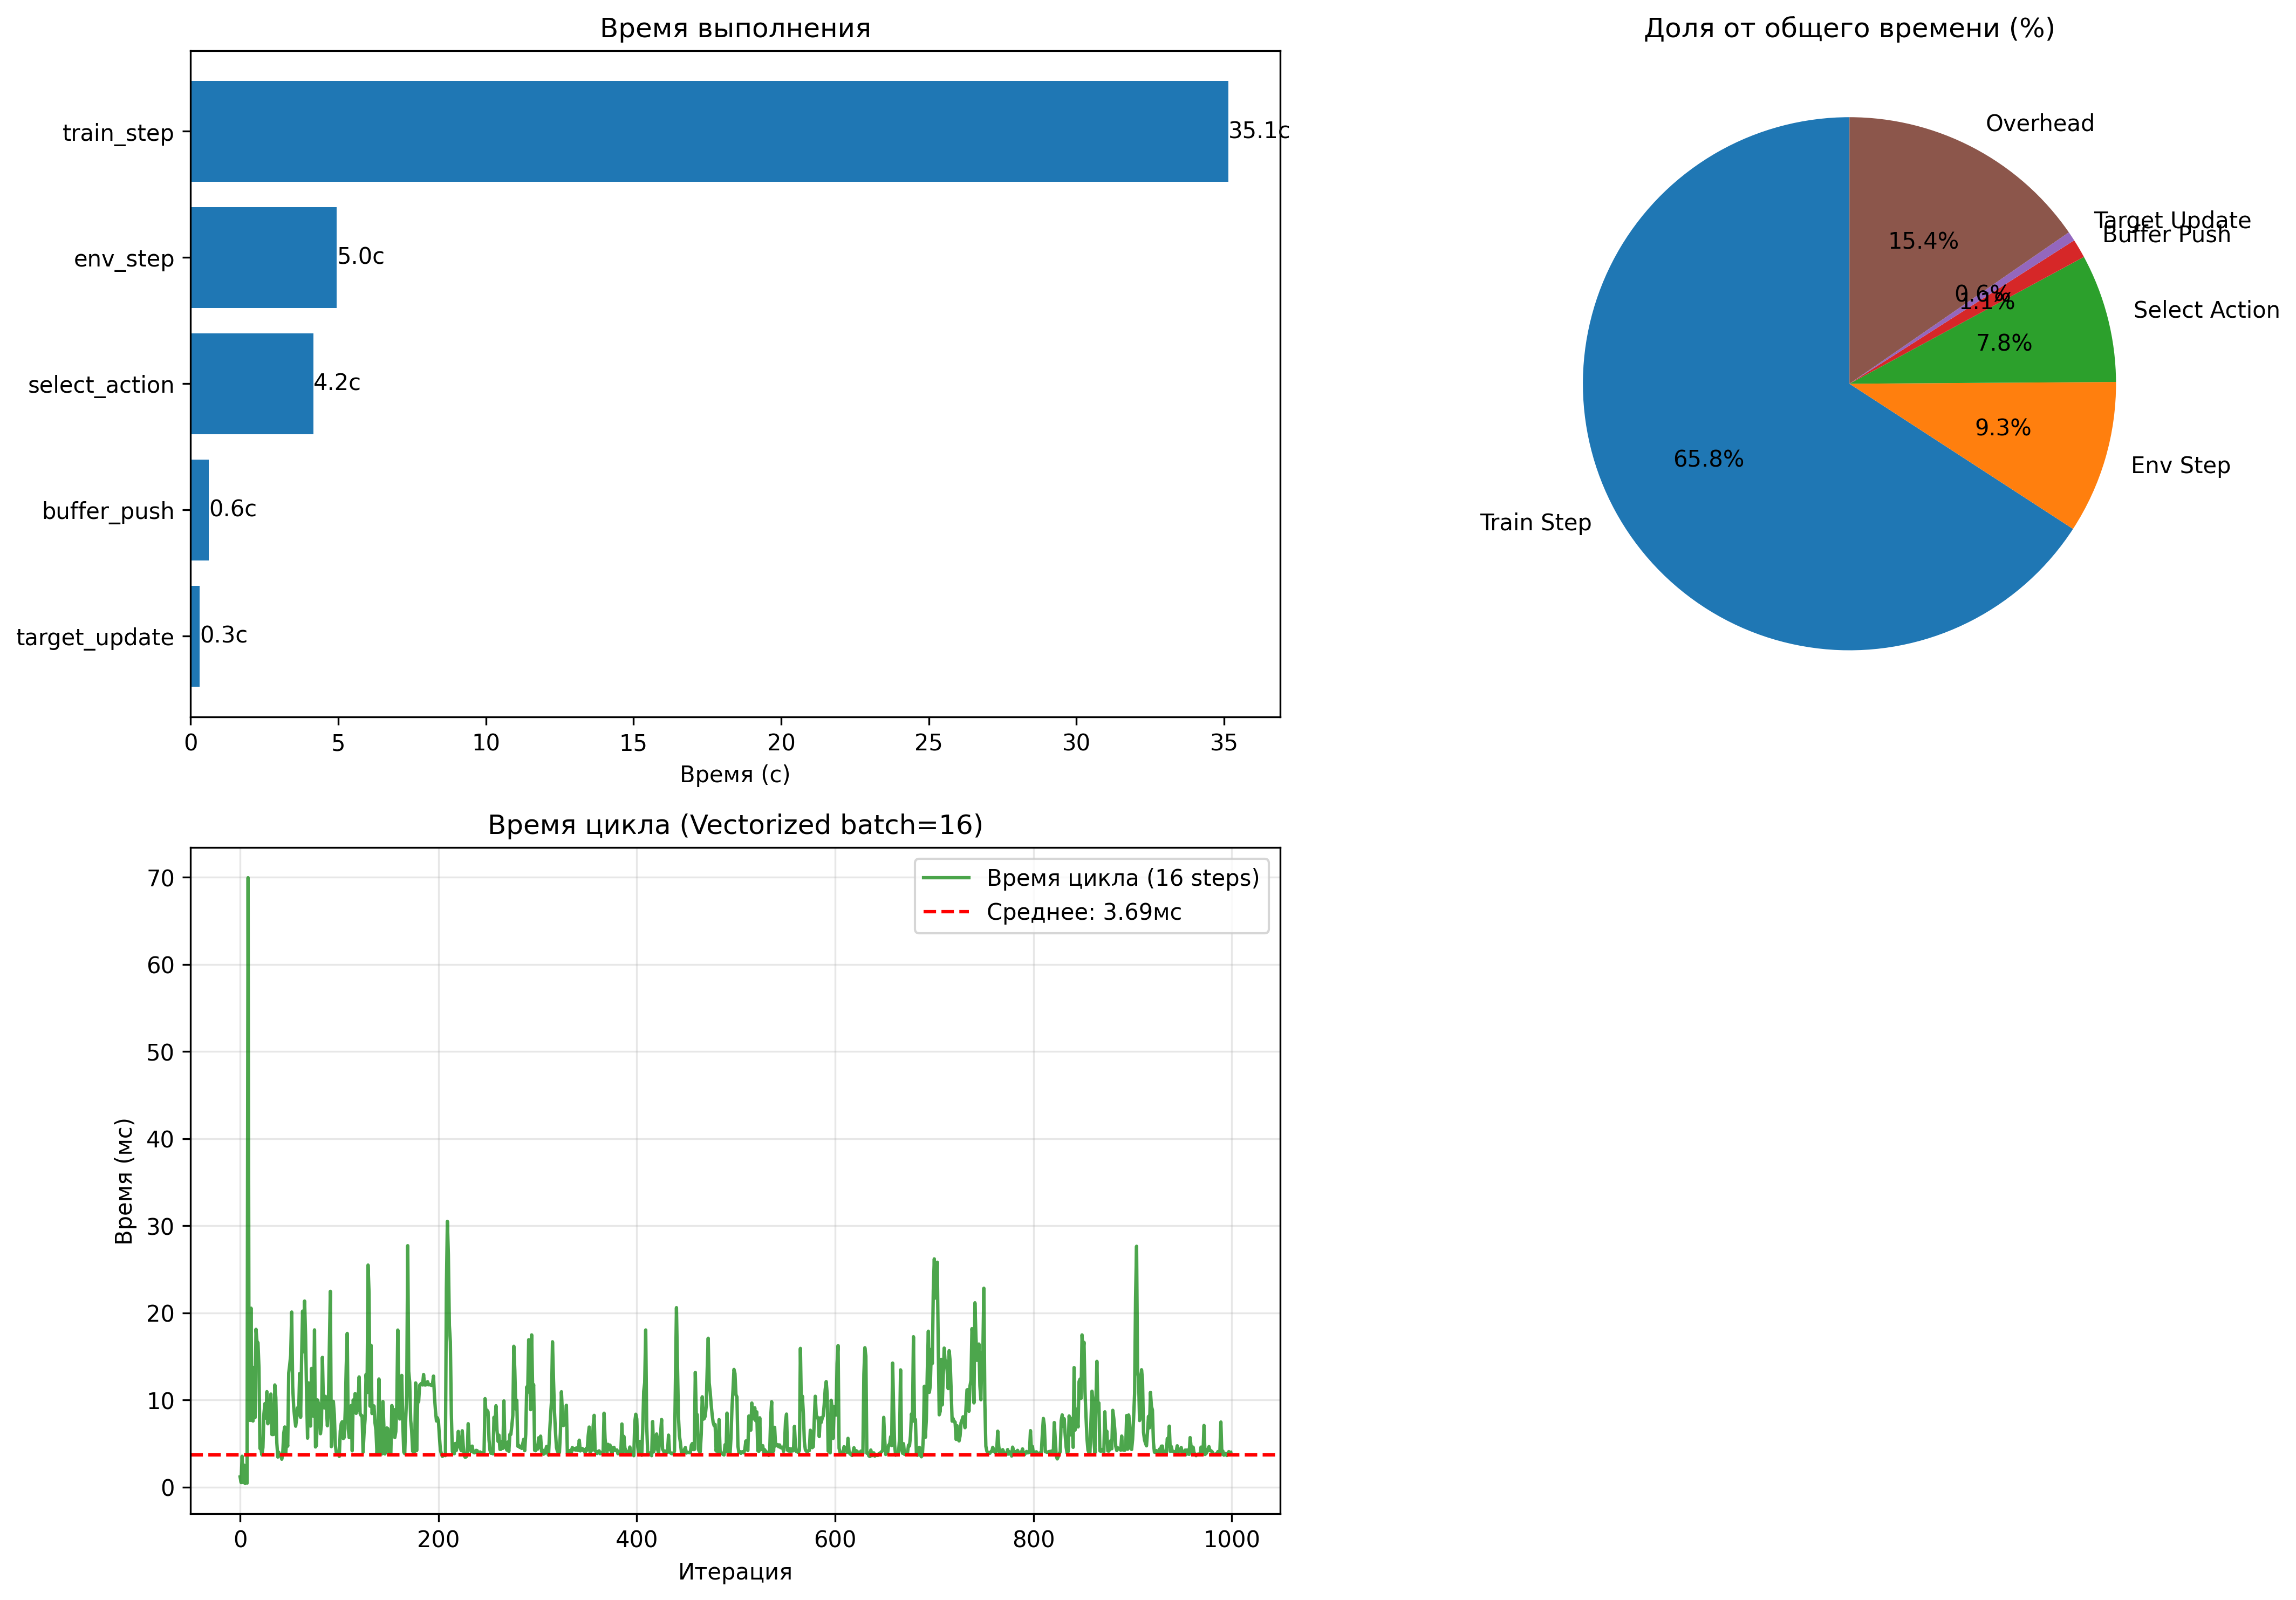

In [ ]:
from IPython.display import Image, display
image_path = 'RL/dqn_full_profiling.png'
try:
    display(Image(filename=image_path, width=1000))
except FileNotFoundError:
    print(f"Ошибка: Файл изображения '{image_path}' не найден.")